
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h1>Homework, Task 1: Import and explore the data (EDA)</h1>

<p>This homework uses repeat-purchase data from Everything & Then Some. Each row of train.csv is a single purchase, and the target repeat_purchase_90d indicates whether the same customer made another purchase within 90 days (1) or not (0). The overall goal is to predict this target for unseen purchases.</p>

<p>This notebook covers Task 1 only. We import train.csv and the supplementary customer table clientes.csv, describe the observations and variables, compute descriptive statistics, and check the data for missing values, implausible values and inconsistencies. We then explore the variables individually, in relation to the target and to each other, and check how stable the data is over time.</p>

<p>The data is left unchanged here. Every issue we find is documented and carried over as an open decision to Task 2, where cleaning and pre-processing take place. test.csv is deliberately not loaded: it is reserved for evaluating the final model, and using it now would let test information influence our decisions (data leakage).</p>

<h2>Contents</h2>

<ol>
  <li><a href="#setup">Setup and import</a></li>
  <li><a href="#vars">Observations and variables</a></li>
  <li><a href="#target">The target</a></li>
  <li><a href="#desc">Descriptive statistics</a></li>
  <li><a href="#quality">Data quality and inconsistencies</a></li>
  <li><a href="#clientes">The auxiliary table clientes.csv</a></li>
  <li><a href="#uni">Univariate distributions</a></li>
  <li><a href="#bi">Bivariate relationships with the target</a></li>
  <li><a href="#multi">Multivariate relationships</a></li>
  <li><a href="#shift">Stability over time within train</a></li>
  <li><a href="#summary">Summary of insights and implications for Task 2</a></li>
</ol>

</div>

<div 
style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">
<a id="setup"></a>
<h2>Setup and Import</h2>
</div>

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import roc_auc_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# One consistent look for every figure: two colours for the two target classes,
# one blue ramp for magnitudes, a blue-grey-red diverging map for correlations.
sns.set_theme(style="whitegrid", context="notebook")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"
CLASS_COLORS = {0: BLUE, 1: ORANGE}
DIVERGING = sns.blend_palette(["#1c5cab", "#f0efec", "#d03b3b"], as_cmap=True)
FIGSIZE = (11, 4.5)

DATA_DIR = Path("data")
TARGET = "repeat_purchase_90d"

In [4]:
DATA_DIR = Path.home() / "Downloads" / "Project" / "data"

train = pd.read_csv(DATA_DIR / "train.csv")
clientes = pd.read_csv(DATA_DIR / "clientes.csv")

pd.DataFrame(
    {name: {"rows": df.shape[0], "columns": df.shape[1]}
     for name, df in [("train", train), ("clientes", clientes)]}
).T

,rows,columns
train,6534,39
clientes,1143,13


In [5]:
print("Customer Id unique in clientes.csv:", clientes["customer_id"].is_unique)
found = train["customer_id"].drop_duplicates().isin(clientes["customer_id"]).sum()
print(f"Customers of train.csv found in clientes.csv: {found} of {train['customer_id'].nunique()}")

train.head()

Customer Id unique in clientes.csv: True
Customers of train.csv found in clientes.csv: 610 of 610


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,repeat_purchase_90d,days_since_previous_purchase,customer_tenure_days,prior_purchase_count,prior_total_spend,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days,purchase_count_30d,spend_30d,purchase_count_90d,spend_90d,purchase_count_180d,spend_180d,purchase_count_365d,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,ID,random_noise
0,558.110,510.900,453.750,104.360,0.000,0.000,57.150,153.100,4.000,1.000,1,79.000,126.000,2.000,858.300,429.150,112.656,349.490,508.810,47.000,NaN,0.000,0.000,1.000,349.490,2.000,858.300,2.000,858.300,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,10000000,-0.660
1,978.800,830.020,795.770,183.030,0.000,0.000,34.250,472.943,32.000,1.000,1,244.000,616.000,5.000,"6,722.830","1,344.566","1,683.795",84.380,"4,222.150",93.000,117.658,0.000,0.000,0.000,0.000,0.000,0.000,4.000,"2,500.680",189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,10000001,0.925
2,10.330,12.000,8.400,1.930,0.000,0.000,3.600,6.097,1.000,1.000,1,9.000,610.000,90.000,"17,590.080",195.445,190.390,4.540,"1,002.150",6.753,6.384,2.000,111.270,9.000,"1,928.550",28.000,"5,290.250",49.000,"7,899.800",103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,10000002,-0.259
3,856.830,696.610,696.610,160.220,0.000,0.000,0.000,408.167,9.000,1.000,0,97.000,97.000,1.000,270.330,270.330,NaN,270.330,270.330,NaN,NaN,0.000,0.000,0.000,0.000,1.000,270.330,1.000,270.330,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,10000003,1.448
4,"1,616.100","1,488.850","1,313.900",302.200,0.000,0.000,174.950,485.402,33.000,1.000,1,85.000,"1,575.000",25.000,"12,803.020",512.121,406.697,22.580,"1,736.740",62.083,66.247,0.000,0.000,2.000,184.130,4.000,"2,062.500",4.000,"2,062.500",122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,10000004,-1.059


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight:</b>
<p><b>Two files, one key.</b> train.csv has <b>6,534 rows × 39 columns</b>: 37 features, the row key ID and the target repeat_purchase_90d. clientes.csv holds <b>1,143 customers × 13 columns</b> and joins to train through customer_id.</p>

</div>

<a id="vars"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>2. Observations and variables</h2>

<h3>2.1 What one row is</h3>

</div>

In [6]:
print(f"ID unique in train: {train['ID'].is_unique}") # True if no ID appears twice

rows_per_customer = train.groupby("customer_id").size()
n_customers = train["customer_id"].nunique()
single_row = (rows_per_customer == 1).sum()
top10_rows = rows_per_customer.nlargest(10).sum()

print(f"train: {len(train):,} rows from {n_customers:,} customers")
print("\nRows per customer:")
print(rows_per_customer.describe().round(1).to_string())
print(f"\ncustomers with exactly one row: {single_row}")
print(f"Top 10 customers hold {top10_rows:,} rows ({top10_rows / len(train):.1%})")
# A random split puts purchases of the same big customer in both training and validation, so the model can recognise the customer and the score looks better than it really is.

dates_train = pd.to_datetime(train["purchase_date"])
print(f"\nPurchase date: {dates_train.min().date()} to {dates_train.max().date()}")

ID unique in train: True
train: 6,534 rows from 610 customers

Rows per customer:
count   610.000
mean     10.700
std      20.000
min       1.000
25%       1.000
50%       4.000
75%      12.000
max     277.000

customers with exactly one row: 157
Top 10 customers hold 1,145 rows (17.5%)

Purchase date: 2015-07-11 to 2025-02-15


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: one row is one purchase, and rows are not independent.</b></p>

<ul>
  <li>ID is unique, so it identifies the row and carries no meaning.</li>
  <li>The <b>6,534 rows come from only 610 customers</b>. The median customer has 4 rows, 157 customers have just one, and the 10 heaviest customers alone hold <b>17.5%</b> of all rows (the largest has 277). Rows of the same customer share history, so a random train/validation split would put the same customer on both sides. Validation in Task 4 should be grouped by customer_id (or split by time).</li>
  <li><b>Train covers almost ten years</b>, from <b>2015-07-11 to 2025-02-15</b>. Section 10 checks whether the population and the coding of the variables stay stable over that period.</li>
</ul>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>2.2 Variable dictionary and roles</h3>

<p>Some column names are in Portuguese, because the data is an invoice export from an ERP system. Each variable is assigned a role below, and this role, not its data type, determines how it is treated in the rest of the notebook.</p>

</div>

In [7]:
INVOICE = ["Total a Pagar", "Total Bruto", "Total Liquido", "Total Imp_", "Total Portes",
           "Total Desc_ Global", "Total Desc_ Linha", "Custo", "N_ Detalhes",
           "invoice_count_current_purchase"]
HISTORY = ["days_since_previous_purchase", "customer_tenure_days", "prior_purchase_count",
           "prior_total_spend", "prior_mean_purchase_value", "prior_std_purchase_value",
           "prior_min_purchase_value", "prior_max_purchase_value", "prior_mean_gap_days",
           "prior_std_gap_days"]
WINDOWS = ["purchase_count_30d", "spend_30d", "purchase_count_90d", "spend_90d",
           "purchase_count_180d", "spend_180d", "purchase_count_365d", "spend_365d"]
CATEGORICAL = ["payment_type", "salesperson", "commercial_zone", "transport_method",
               "warehouse", "document_series"]
IDENTIFIERS = ["ID", "customer_id"]
NUMERIC = INVOICE + HISTORY + WINDOWS

#here we can name the tables: 
meaning = {
    "Total a Pagar": "amount payable (net + VAT)", "Total Bruto": "gross amount before discounts",
    "Total Liquido": "net amount after discounts, excl. VAT", "Total Imp_": "tax (VAT) amount",
    "Total Portes": "shipping charge", "Total Desc_ Global": "document-level discount",
    "Total Desc_ Linha": "sum of line-level discounts", "Custo": "cost of goods sold",
    "N_ Detalhes": "number of invoice lines", "invoice_count_current_purchase": "invoices in this purchase",
    "days_since_previous_purchase": "recency: days since the customer's previous purchase",
    "customer_tenure_days": "days since the customer's first purchase",
    "prior_purchase_count": "number of earlier purchases", "prior_total_spend": "total earlier spend",
    "prior_mean_purchase_value": "mean value of earlier purchases",
    "prior_std_purchase_value": "std of earlier purchase values",
    "prior_min_purchase_value": "smallest earlier purchase", "prior_max_purchase_value": "largest earlier purchase",
    "prior_mean_gap_days": "mean days between earlier purchases",
    "prior_std_gap_days": "std of days between earlier purchases",
    "payment_type": "payment terms code", "salesperson": "salesperson code",
    "commercial_zone": "commercial zone code", "transport_method": "delivery method code",
    "warehouse": "warehouse code", "document_series": "invoice document series",
    "purchase_date": "date of the purchase", "ID": "row identifier (submission key)",
    "customer_id": "customer key (joins to clientes.csv)", "random_noise": "pure noise column",
    TARGET: "1 = customer purchases again within 90 days",
}
for w in [30, 90, 180, 365]:
    meaning[f"purchase_count_{w}d"] = f"purchases in the {w} days before this one"
    meaning[f"spend_{w}d"] = f"spend in the {w} days before this one"

def role(c):
    if c == TARGET: return "target"
    if c in IDENTIFIERS: return "identifier"
    if c in INVOICE: return "current purchase (invoice)"
    if c in HISTORY: return "customer history"
    if c in WINDOWS: return "rolling window"
    if c in CATEGORICAL: return "categorical code"
    if c == "purchase_date": return "date"
    return "noise"

dictionary = pd.DataFrame({
    "role": [role(c) for c in train.columns],
    "meaning": [meaning[c] for c in train.columns],
    "dtype": train.dtypes.astype(str).values,
    "n_unique": train.nunique().values,
    "% missing": (100 * train.isna().mean()).round(2).values,
}, index=train.columns)
dictionary.sort_values("role")

,role,meaning,dtype,n_unique,% missing
payment_type,categorical code,payment terms code,object,9,3.980
salesperson,categorical code,salesperson code,object,9,3.960
commercial_zone,categorical code,commercial zone code,object,5,0.990
transport_method,categorical code,delivery method code,object,80,3.990
warehouse,categorical code,warehouse code,object,2,3.980
document_series,categorical code,invoice document series,object,3,0.990
Total a Pagar,current purchase (invoice),amount payable (net + VAT),float64,6122,0.990
invoice_count_current_purchase,current purchase (invoice),invoices in this purchase,float64,5,0.990
N_ Detalhes,current purchase (invoice),number of invoice lines,float64,171,0.990
Custo,current purchase (invoice),cost of goods sold,float64,5740,0.990


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: five blocks of variables, not 39 independent ones.</b></p>

<table>
  <tr><th>block</th><th>columns</th><th>what it describes</th></tr>
  <tr><td>current purchase (invoice)</td><td>10</td><td>amounts, discounts, tax, shipping, cost and size of <i>this</i> purchase</td></tr>
  <tr><td>customer history</td><td>10</td><td>recency, tenure, number, value and spacing of <i>earlier</i> purchases</td></tr>
  <tr><td>rolling windows</td><td>8</td><td>count and spend in the 30/90/180/365 days <i>before</i> this purchase</td></tr>
  <tr><td>categorical codes</td><td>6</td><td>payment terms, salesperson, zone, delivery method, warehouse, document series</td></tr>
  <tr><td>other</td><td>5</td><td>ID, customer_id, purchase_date, random_noise, target</td></tr>
</table>

<p>The categorical levels are anonymised labels ("Maybe Tomorrow Payment 7", "VLOOKUP Master 1"), so their meaning has to come from the data, not the name. The numeric columns are read as float64 only because of the empty rows found in Section 5.1; counts such as N_ Detalhes are integers in reality.</p>

</div>

<a id="target"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>3. The target</h2>

</div>

,Rows,Share
Repeat purchase,,
0 = No repeat,"2,880",44.1%
1 = Repeat,"3,654",55.9%


Majority class baseline accuracy: 0.5592


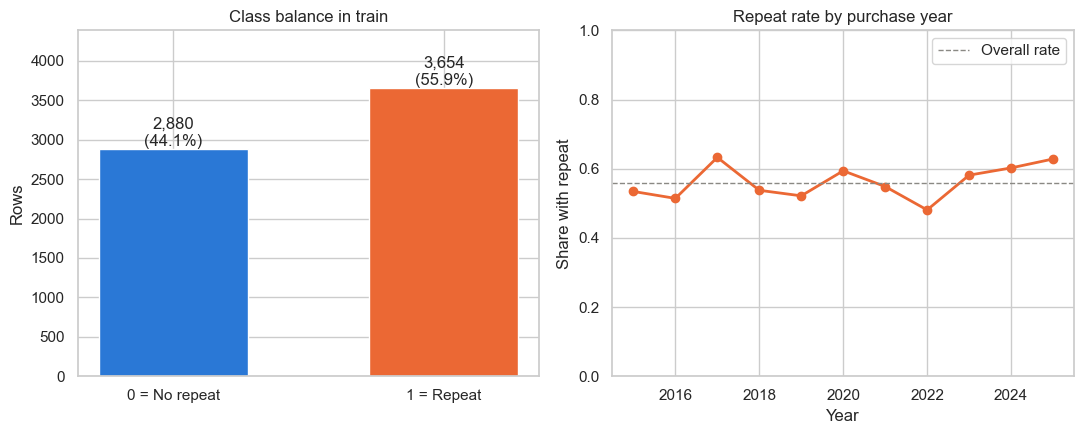

Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Repeat rate,53.4%,51.4%,63.3%,53.8%,52.2%,59.4%,54.9%,48.1%,58.1%,60.2%,62.8%
Purchases,335,420,670,716,646,670,782,628,767,757,78


In [15]:
balance = train[TARGET].value_counts().sort_index()
display(balance.to_frame("Rows").assign(Share=balance / balance.sum())
        .rename(index={0: "0 = No repeat", 1: "1 = Repeat"})
        .rename_axis("Repeat purchase")
        .style.format({"Rows": "{:,}", "Share": "{:.1%}"}))
print(f"Majority class baseline accuracy: {balance.max() / balance.sum():.4f}")

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
axes[0].bar(["0 = No repeat", "1 = Repeat"], balance.values, color=[BLUE, ORANGE], width=0.55)
for i, v in enumerate(balance.values):
    axes[0].text(i, v, f"{v:,}\n({v / balance.sum():.1%})", ha="center", va="bottom")
axes[0].set(title="Class balance in train", ylabel="Rows", ylim=(0, balance.max() * 1.2))

by_year = train.groupby(dates_train.dt.year)[TARGET].agg(["mean", "size"])
by_year.index = by_year.index.astype(int)
axes[1].plot(by_year.index, by_year["mean"], marker="o", color=ORANGE, lw=2)
axes[1].axhline(train[TARGET].mean(), color=GREY, ls="--", lw=1, label="Overall rate")
axes[1].set(title="Repeat rate by purchase year", ylabel="Share with repeat",
            xlabel="Year", ylim=(0, 1))
axes[1].legend()
plt.tight_layout(); plt.show()

year_table = (by_year.rename(columns={"mean": "Repeat rate", "size": "Purchases"})
                     .rename_axis("Year").T)
year_table.style.format("{:.1%}", subset=pd.IndexSlice["Repeat rate", :]) \
                .format("{:,.0f}", subset=pd.IndexSlice["Purchases", :]) \
                .set_caption("Repeat rate and number of purchases per year")

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: the classes are slightly imbalanced and stable over time.</b></p>

<ul>
  <li><b>3,654 repeats (55.9%)</b> against <b>2,880 non-repeats (44.1%)</b>. Always predicting "repeat" already scores <b>0.559 accuracy</b>, so accuracy alone flatters a model. Task 4 should report a metric that looks at both classes (e.g. ROC AUC, F1 or balanced accuracy) and compare it against this baseline.</li>
  <li>The yearly repeat rate moves between <b>0.48 (2022)</b> and <b>0.63 (2017, 2025)</b> without a trend. The 2025 value rests on only 78 rows, because the data ends in February 2025. There is no sign that the definition of the target changed over the years.</li>
</ul>

</div>

<a id="desc"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>4. Descriptive statistics</h2>

<h3>4.1 Numeric variables</h3>

<p>The standard describe() output is extended with the skewness, the share of exact zeros and the ratio of mean to median. These three measures show whether mean and standard deviation are meaningful summaries of a variable at all.</p>

</div>

In [16]:
# Statistics on the rows that carry values: 65 rows are completely empty and would otherwise deflate the share of zeros.
num = train[NUMERIC + ["random_noise"]].dropna(how="all")
desc = num.describe().T
desc["median"] = num.median()
desc["mean/median"] = desc["mean"] / desc["median"].replace(0, np.nan)
desc["skew"] = num.skew()
desc["% zeros"] = 100 * (num == 0).mean()
desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "mean/median", "skew", "% zeros"]]

,count,mean,std,min,25%,50%,75%,max,mean/median,skew,% zeros
Total a Pagar,"6,469.000",925.556,"1,334.998",0.930,188.920,476.740,"1,087.670","22,297.210",1.941,4.209,0.000
Total Bruto,"6,469.000",886.153,"1,327.641",0.830,175.740,445.740,"1,036.700","21,578.280",1.988,4.313,0.000
Total Liquido,"6,469.000",773.336,"1,136.356",0.760,154.380,389.910,903.370,"18,127.810",1.983,4.152,0.000
Total Imp_,"6,469.000",152.220,225.262,0.000,29.930,79.740,184.840,"4,169.400",1.909,4.836,3.293
Total Portes,"6,469.000",1.151,5.844,0.000,0.000,0.000,0.000,181.060,NaN,19.549,83.722
Total Desc_ Global,"6,469.000",0.350,5.117,0.000,0.000,0.000,0.000,218.490,NaN,27.458,98.300
Total Desc_ Linha,"6,469.000",112.466,289.986,0.000,0.000,13.130,92.280,"4,103.440",8.566,5.923,37.734
Custo,"6,469.000",328.165,519.507,0.000,49.050,152.540,396.061,"7,427.401",2.151,4.611,7.513
N_ Detalhes,"6,469.000",21.525,27.713,1.000,4.000,11.000,29.000,423.000,1.957,2.981,0.000
invoice_count_current_purchase,"6,469.000",1.066,0.311,1.000,1.000,1.000,1.000,5.000,1.066,6.436,0.000


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: almost every numeric column is strongly right-skewed, and four columns contain impossible values.</b></p>

<ul>
  <li>Amounts are skewed with <b>skewness between 4 and 6</b> and a mean about twice the median (Total a Pagar: mean 925.6, median 476.7). The mean and standard deviation describe the tail, not the typical purchase; medians and quartiles are the honest summary, and a log transform is a natural candidate in Task 2.</li>
  <li>Several columns are <b>mostly zero</b>: Total Desc_ Global (98.3% zeros), Total Portes (83.7%), Total Desc_ Linha (37.7%). For these, "zero vs. non-zero" may matter more than the amount.</li>
  <li><b>9.2% of rows</b> have prior_purchase_count = 0 (the customer's first purchase), which is why tenure, prior spend and prior count have exactly the same share of zeros.</li>
  <li>prior_mean_purchase_value and spend_365d reach <b>1,000,000,000</b> and have negative minima, and the day columns days_since_previous_purchase and prior_mean_gap_days go down to <b>−4</b>. None of these is a possible value. Section 5.4 examines them; their effect is visible here already: the mean of prior_mean_purchase_value is <b>2.8 million</b> against a median of 725.</li>
  <li>random_noise has mean ≈ 0 and std ≈ 1: it is a standard-normal column, as its name says.</li>
</ul>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>4.2 Categorical variables</h3>

</div>

In [8]:
# The 65 empty rows (Section 5.1) are left out so that "% missing" counts real gaps only.
filled_cat = train.loc[train["purchase_date"].notna(), CATEGORICAL]
cat_summary = pd.DataFrame({
    "n_levels": filled_cat.nunique(),
    "most frequent": filled_cat.mode().iloc[0],
    "share of most frequent": filled_cat.apply(lambda s: s.value_counts(normalize=True).iloc[0]),
    "levels with < 30 rows": filled_cat.apply(lambda s: (s.value_counts() < 30).sum()),
    "% missing": 100 * filled_cat.isna().mean(),
})
cat_summary

,n_levels,most frequent,share of most frequent,levels with < 30 rows,% missing
payment_type,9,Maybe Tomorrow Payment 7,0.728,4,3.014
salesperson,9,VLOOKUP Master 1,0.646,3,2.999
commercial_zone,5,Decorative Dashboard Zone 4,0.968,2,0.000
transport_method,80,Maybe Tomorrow Delivery 72,0.178,51,3.030
warehouse,2,Final Excel Warehouse 1,0.997,1,3.014
document_series,3,Ctrl Z Series 2,0.423,0,0.000


In [22]:
for col in CATEGORICAL:
    if col == "transport_method":
        continue
    counts = train[col].value_counts(dropna=False)
    counts.index = counts.index.fillna("(missing)")
    display(counts.to_frame("Rows").assign(Share=counts / counts.sum())
            .rename_axis(col)
            .style.format({"Rows": "{:,}", "Share": "{:.1%}"})
            .set_table_attributes('style="width:100%"'))

,Rows,Share
payment_type,,
Maybe Tomorrow Payment 7,"4,565",69.9%
Maybe Tomorrow Payment 12,991,15.2%
Maybe Tomorrow Payment 9,502,7.7%
(missing),260,4.0%
Maybe Tomorrow Payment 10,134,2.1%
Maybe Tomorrow Payment 8,40,0.6%
Maybe Tomorrow Payment 2,21,0.3%
Maybe Tomorrow Payment 4,9,0.1%
Maybe Tomorrow Payment 11,8,0.1%


,Rows,Share
salesperson,,
VLOOKUP Master 1,"4,054",62.0%
VLOOKUP Master 4,"1,461",22.4%
VLOOKUP Master 9,384,5.9%
(missing),259,4.0%
VLOOKUP Master 7,201,3.1%
VLOOKUP Master 2,123,1.9%
VLOOKUP Master 3,30,0.5%
VLOOKUP Master 6,12,0.2%
VLOOKUP Master 5,7,0.1%


,Rows,Share
commercial_zone,,
Decorative Dashboard Zone 4,"6,260",95.8%
Decorative Dashboard Zone 2,151,2.3%
(missing),65,1.0%
Decorative Dashboard Zone 3,56,0.9%
Decorative Dashboard Zone 6,1,0.0%
Decorative Dashboard Zone 7,1,0.0%


,Rows,Share
warehouse,,
Final Excel Warehouse 1,"6,253",95.7%
(missing),260,4.0%
Final Excel Warehouse 3,21,0.3%


,Rows,Share
document_series,,
Ctrl Z Series 2,"2,738",41.9%
Ctrl Z Series 3,"1,903",29.1%
Ctrl Z Series 1,"1,828",28.0%
(missing),65,1.0%


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: almost every categorical variable is dominated by one level and has a long tail of rare ones.</b></p>

<ul>
  <li>commercial_zone (<b>96.8% Zone 4</b>) and warehouse (<b>99.7% Warehouse 1</b>) are almost constant in train and can carry little information there.</li>
  <li>transport_method has <b>80 levels</b>, 51 of them with fewer than 30 rows; the top 10 cover 66.4% of the non-missing rows. One-hot encoding it as is would create 80 sparse columns, so rare levels need grouping in Task 2.</li>
  <li>payment_type and salesperson each have <b>9 levels</b> with 3–4 rare ones.</li>
  <li>document_series is balanced across three series, but Section 10 shows it is a <b>proxy for time</b>.</li>
  <li>Four of the six categoricals miss <b>about 3%</b> of their values.</li>
</ul>

</div>

<a id="quality"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>5. Data quality and inconsistencies</h2>

<p>Each check below follows from what a column <i>means</i>: the rule is stated first and then measured on the data.</p>

<h3>5.1 Empty rows</h3>

</div>

In [25]:
feature_cols = [c for c in train.columns if c not in IDENTIFIERS + [TARGET]]
empty_rows = train[feature_cols].isna().all(axis=1)
print(f"Rows with every feature missing: {empty_rows.sum()} "
      f"({empty_rows.mean():.2%}); Repeat rate among them: {train.loc[empty_rows, TARGET].mean():.3f}")
train.loc[empty_rows].head()

Rows with every feature missing: 65 (0.99%); Repeat rate among them: 0.508


,Total a Pagar,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,repeat_purchase_90d,days_since_previous_purchase,customer_tenure_days,prior_purchase_count,prior_total_spend,prior_mean_purchase_value,prior_std_purchase_value,prior_min_purchase_value,prior_max_purchase_value,prior_mean_gap_days,prior_std_gap_days,purchase_count_30d,spend_30d,purchase_count_90d,spend_90d,purchase_count_180d,spend_180d,purchase_count_365d,spend_365d,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,ID,random_noise
393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,755628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000457,NaN
484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,755628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000560,NaN
582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,427118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000678,NaN
583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,508217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000679,NaN
748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,427118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10000870,NaN


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: 65 rows (0.99%) are completely empty.</b> They carry a target, an ID and a customer_id but no feature at all, not even purchase_date. Their repeat rate (0.508) is close to the overall rate, so they hold no learnable information and are candidates for removal in Task 2. All statistics from Section 5.3 on exclude them.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.2 Duplicates</h3>

</div>

In [27]:
print("exact duplicates (all columns):", train.duplicated().sum())
dup_mask = train.drop(columns="ID").duplicated(keep=False)
print("duplicates ignoring ID:", train.drop(columns="ID").duplicated().sum(),
      f" rows involved: {dup_mask.sum()}, of which empty rows: {(dup_mask & empty_rows).sum()}")
non_empty = train.loc[~empty_rows]
print("duplicates ignoring ID, non-empty rows only:", non_empty.drop(columns="ID").duplicated().sum())
print("same customer on the same date twice:",
      non_empty.duplicated(subset=["customer_id", "purchase_date"]).sum())

exact duplicates (all columns): 0
duplicates ignoring ID: 10  rows involved: 16, of which empty rows: 16
duplicates ignoring ID, non-empty rows only: 0
same customer on the same date twice: 0


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: No duplicated purchases.</b> The 10 duplicates that appear when ID is ignored are all among the empty rows: 16 empty rows from 6 customers, where empty rows of the same customer with the same target look identical. Among the real purchases there are <b>no duplicates and no customer with two purchases on the same date</b>.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.3 Missing values</h3>

<p>From here on the 65 empty rows are excluded from the statistics (stored as tr below). This way the remaining pattern of missing values is visible on its own and is not dominated by rows that are missing everything.</p>

</div>

In [28]:
tr = train.loc[~empty_rows].copy()
tr["purchase_date"] = pd.to_datetime(tr["purchase_date"])

missing = pd.DataFrame({
    "missing (all rows)": train.isna().sum(),
    "missing (non-empty rows)": tr.isna().sum(),
    "% (non-empty rows)": (100 * tr.isna().mean()).round(2),
})
missing = missing[missing["missing (all rows)"] > 0].sort_values("missing (non-empty rows)", ascending=False)
missing

,missing (all rows),missing (non-empty rows),% (non-empty rows)
prior_std_gap_days,1478,1413,21.840
prior_mean_gap_days,1308,1243,19.210
prior_std_purchase_value,1113,1048,16.200
prior_mean_purchase_value,862,797,12.320
days_since_previous_purchase,861,796,12.300
prior_min_purchase_value,668,603,9.320
prior_max_purchase_value,668,603,9.320
transport_method,261,196,3.030
payment_type,260,195,3.010
spend_365d,260,195,3.010


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p>Many missing history values are expected, not errors. On a customer's <b>first purchase</b> there is no earlier purchase, so there are no days since the last one. A gap between purchases or a standard deviation needs <b>at least two earlier purchases</b>. The cross-tab below shows how many missing values are explained this way and how many are not.</p>

</div>

In [31]:
prior_bucket = tr["prior_purchase_count"].clip(upper=3).map({0: "0", 1: "1", 2: "2", 3: "3+"})
history_cols = ["days_since_previous_purchase", "prior_mean_purchase_value",
                "prior_min_purchase_value", "prior_std_purchase_value",
                "prior_mean_gap_days", "prior_std_gap_days", "spend_365d"]

structural = pd.DataFrame({col: tr[col].isna().groupby(prior_bucket).mean()
                           for col in history_cols}).T
structural.columns.name = "Earlier purchases"
structural.loc["Rows in group"] = prior_bucket.value_counts().sort_index()

display(structural.style
        .format("{:.1%}", subset=pd.IndexSlice[history_cols, :])
        .format("{:,.0f}", subset=pd.IndexSlice[["Rows in group"], :])
        .background_gradient(cmap="Blues", vmin=0, vmax=1, subset=pd.IndexSlice[history_cols, :])
        .set_caption("Share of missing values by number of earlier purchases")
        .set_table_attributes('style="width:100%"'))

Earlier purchases,0,1,2,3+
days_since_previous_purchase,100.0%,4.3%,5.5%,3.0%
prior_mean_purchase_value,100.0%,4.5%,3.0%,3.2%
prior_min_purchase_value,100.0%,0.0%,0.0%,0.0%
prior_std_purchase_value,100.0%,100.0%,0.0%,0.0%
prior_mean_gap_days,100.0%,100.0%,5.8%,3.4%
prior_std_gap_days,100.0%,100.0%,100.0%,0.0%
spend_365d,3.0%,4.3%,4.1%,2.8%
Rows in group,603,445,365,"5,056"


In [33]:
# Does missingness carry information about the target?
flags = {
    "Recency missing": tr["days_since_previous_purchase"].isna(),
    "First purchase (no earlier purchases)": tr["prior_purchase_count"].eq(0),
    "Recency missing although earlier purchases exist": tr["days_since_previous_purchase"].isna() & tr["prior_purchase_count"].ge(1),
    "Payment type missing": tr["payment_type"].isna(),
    "Salesperson missing": tr["salesperson"].isna(),
    "Transport method missing": tr["transport_method"].isna(),
    "Spend in last 365 days missing": tr["spend_365d"].isna(),
}
miss_info = pd.DataFrame({
    "Rows flagged": {k: v.sum() for k, v in flags.items()},
    "Repeat rate if flagged": {k: tr.loc[v, TARGET].mean() for k, v in flags.items()},
    "Repeat rate otherwise": {k: tr.loc[~v, TARGET].mean() for k, v in flags.items()},
})
miss_info["Difference"] = miss_info["Repeat rate if flagged"] - miss_info["Repeat rate otherwise"]

display(miss_info.rename_axis("Condition").style
        .format({"Rows flagged": "{:,}", "Repeat rate if flagged": "{:.1%}",
                 "Repeat rate otherwise": "{:.1%}", "Difference": "{:+.1%}"})
        .background_gradient(cmap="RdBu", vmin=-0.3, vmax=0.3, subset=["Difference"])
        .set_caption("Repeat rate with and without each missing-value condition")
        .set_table_attributes('style="width:100%"'))

,Rows flagged,Repeat rate if flagged,Repeat rate otherwise,Difference
Condition,,,,
Recency missing,796,39.1%,58.3%,-19.3%
First purchase (no earlier purchases),603,33.3%,58.3%,-25.0%
Recency missing although earlier purchases exist,193,57.0%,55.9%,+1.1%
Payment type missing,195,56.4%,56.0%,+0.4%
Salesperson missing,194,59.8%,55.9%,+3.9%
Transport method missing,196,55.1%,56.0%,-0.9%
Spend in last 365 days missing,195,56.4%,56.0%,+0.4%


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: Most missing values are structural, a smaller part looks injected at random, and only the structural part predicts the target.</b></p>

<ol>
  <li><b>Structural (explained by the history length).</b> All <b>603 first purchases</b> (prior_purchase_count = 0) miss every history statistic, because there is nothing to compute it from. With one earlier purchase there is no standard deviation and no gap (445 rows); with two there is one gap but no gap standard deviation (365 rows). These blanks mean "not defined", not "unknown", and are best encoded as such (e.g. an indicator plus a neutral fill), not imputed with a median.</li>
  <li><b>Unexplained.</b> Beyond that pattern, days_since_previous_purchase (193 rows), prior_mean_purchase_value (194), prior_mean_gap_days (195), spend_365d (195) and four categoricals (≈195 rows each, ~3%) are missing although the value should exist. spend_365d is missing even for first purchases, where its true value is simply 0.</li>
  <li><b>Only the structural flag matters for the target.</b> A missing recency has a repeat rate of <b>0.391</b> against <b>0.583</b> otherwise, which is entirely the first-purchase effect (first purchases: 0.333). The unexplained gaps have repeat rates of 0.55–0.60, the same as the rows without gaps, which is consistent with values missing at random; median or mode imputation (fitted on train only) is defensible for them.</li>
</ol>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.4 Impossible values and placeholder codes</h3>

<p>Each column has a valid range: amounts, counts and durations must be ≥ 0, and a mean must lie between the minimum and the maximum. Values outside this range are not extreme values, they are not valid values at all.</p>

</div>

In [34]:
checks = ["prior_mean_purchase_value", "spend_365d", "days_since_previous_purchase", "prior_mean_gap_days"]
rows = []
for col in checks:
    s = tr[col]
    rows.append({"column": col, "max": s.max(), "values >= 1e8": (s >= 1e8).sum(),
                 "negative values": (s < 0).sum(),
                 "distinct negative values": sorted(s[s < 0].round(2).unique())[:5]})
pd.DataFrame(rows).set_index("column")

,max,values >= 1e8,negative values,distinct negative values
column,,,,
prior_mean_purchase_value,"1,000,000,000.000",16,16,"[-2478.66, -885.1, -883.51, -779.03, -757.48]"
spend_365d,"1,000,000,000.000",15,15,"[-159115.18, -14740.29, -12638.05, -6795.47, -..."
days_since_previous_purchase,"3,199.000",0,16,[-4.0]
prior_mean_gap_days,"3,199.000",0,16,[-4.0]


In [16]:
# Are the placeholder codes concentrated on particular rows?
sentinel = (tr["prior_mean_purchase_value"] >= 1e8) | (tr["spend_365d"] >= 1e8)
negative = (tr["prior_mean_purchase_value"] < 0) | (tr["spend_365d"] < 0)
neg_days = (tr["days_since_previous_purchase"] < 0) | (tr["prior_mean_gap_days"] < 0)
print(f"rows with 1e9 code: {sentinel.sum()}, with a negative amount: {negative.sum()}, "
      f"with negative days: {neg_days.sum()}; rows with any of these: {(sentinel | negative | neg_days).sum()}")
print("rows where both day columns are negative together:",
      ((tr["days_since_previous_purchase"] < 0) & (tr["prior_mean_gap_days"] < 0)).sum())

rows with 1e9 code: 31, with a negative amount: 31, with negative days: 32; rows with any of these: 94
rows where both day columns are negative together: 0


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: three kinds of impossible values, on 94 rows (1.5%).</b></p>

<ul>
  <li><b>Placeholder 1e9:</b> 16 rows in prior_mean_purchase_value, 15 in spend_365d. A round sentinel, not a real amount.</li>
  <li><b>Negative amounts:</b> another 16 and 15 rows, all with different values (e.g. −2,478.66, −159,115.18), so not a code. For the mean they are <b>flipped signs</b>: all 16 negative means equal exactly −(prior_total_spend / prior_purchase_count), so the true value is known (Section 5.5).</li>
  <li><b>Negative days:</b> days_since_previous_purchase and prior_mean_gap_days are each exactly <b>−4</b> on 16 rows, never on the same row. A single repeated value again points to a code.</li>
</ul>

<p>These are not outliers to be clipped but invalid entries; the natural treatment in Task 2 is to set them to missing and impute. Several can also be <b>recomputed</b> from other columns (e.g. prior_mean_purchase_value = prior_total_spend / prior_purchase_count). Whatever rule is chosen has to be written as a reproducible step, so it can later be applied unchanged to any new data the model scores.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.5 Internal consistency rules</h3>

<p>Some columns in the invoice block and in the history block can be calculated from other columns. Checking these relationships shows (a) which columns are redundant and (b) which rows break a rule.</p>

</div>

In [36]:
close = lambda a, b: np.isclose(a, b, atol=0.02)
# Use the sentinel-free values for the history rules, so one bad code is not counted twice.
h = tr.copy()
for col in ["prior_mean_purchase_value", "spend_365d"]:
    h.loc[(h[col] >= 1e8) | (h[col] < 0), col] = np.nan

rules = {
    "Total a Pagar = Liquido + Imp_": close(tr["Total a Pagar"], tr["Total Liquido"] + tr["Total Imp_"]),
    "Total a Pagar = Liquido + Imp_ + Portes": close(tr["Total a Pagar"], tr["Total Liquido"] + tr["Total Imp_"] + tr["Total Portes"]),
    "Liquido = Bruto - Desc Linha - Desc Global": close(tr["Total Liquido"], tr["Total Bruto"] - tr["Total Desc_ Linha"] - tr["Total Desc_ Global"]),
    "Custo <= Liquido (no sale below cost)": tr["Custo"] <= tr["Total Liquido"],
    "Custo > 0": tr["Custo"] > 0,
    "count_30d <= count_90d <= count_180d <= count_365d": (tr["purchase_count_30d"] <= tr["purchase_count_90d"]) & (tr["purchase_count_90d"] <= tr["purchase_count_180d"]) & (tr["purchase_count_180d"] <= tr["purchase_count_365d"]),
    "count_365d <= prior_purchase_count": tr["purchase_count_365d"] <= tr["prior_purchase_count"],
    "spend_30d <= spend_90d <= spend_180d": (tr["spend_30d"] <= tr["spend_90d"] + 0.01) & (tr["spend_90d"] <= tr["spend_180d"] + 0.01),
    "spend_180d <= spend_365d (valid spend_365d)": (h["spend_180d"] <= h["spend_365d"] + 0.01) | h["spend_365d"].isna(),
    "prior_max <= prior_total_spend": (tr["prior_max_purchase_value"] <= tr["prior_total_spend"] + 0.01) | tr["prior_max_purchase_value"].isna(),
    "spend_365d <= prior_total_spend (valid spend_365d)": (h["spend_365d"] <= h["prior_total_spend"] + 0.01) | h["spend_365d"].isna(),
    "min <= mean <= max (valid mean)": ((h["prior_min_purchase_value"] <= h["prior_mean_purchase_value"] + 0.01) & (h["prior_mean_purchase_value"] <= h["prior_max_purchase_value"] + 0.01)) | h["prior_mean_purchase_value"].isna(),
    "prior_total_spend = mean x count (valid mean)": close(h["prior_total_spend"], h["prior_mean_purchase_value"] * h["prior_purchase_count"]) | h["prior_mean_purchase_value"].isna(),
    "days_since_previous <= tenure": (tr["days_since_previous_purchase"] <= tr["customer_tenure_days"]) | tr["days_since_previous_purchase"].isna(),
}
pd.DataFrame({"rows satisfying": {k: int(v.sum()) for k, v in rules.items()},
              "rows violating": {k: int((~v).sum()) for k, v in rules.items()},
              "% satisfying": {k: round(100 * v.mean(), 2) for k, v in rules.items()}})

,rows satisfying,rows violating,% satisfying
Total a Pagar = Liquido + Imp_,6469,0,100.000
Total a Pagar = Liquido + Imp_ + Portes,5416,1053,83.720
Liquido = Bruto - Desc Linha - Desc Global,6469,0,100.000
Custo <= Liquido (no sale below cost),6430,39,99.400
Custo > 0,5983,486,92.490
count_30d <= count_90d <= count_180d <= count_365d,6469,0,100.000
count_365d <= prior_purchase_count,6469,0,100.000
spend_30d <= spend_90d <= spend_180d,6469,0,100.000
spend_180d <= spend_365d (valid spend_365d),6469,0,100.000
prior_max <= prior_total_spend,6424,45,99.300


In [38]:
ship = tr["Total Portes"] > 0
bad_mean = ~rules["min <= mean <= max (valid mean)"]
bad_max = ~rules["prior_max <= prior_total_spend"]
neg_mean = tr["prior_mean_purchase_value"] < 0
implied_mean = tr["prior_total_spend"] / tr["prior_purchase_count"]

rows = [
    ("Invoices with a shipping charge", f"{ship.sum():,}",
     "Rows where shipping (Total Portes) was charged"),
    ("…of which: Pagar = Liquido + Imp_ still holds", f"{rules['Total a Pagar = Liquido + Imp_'][ship].mean():.0%}",
     "Shipping is already included in the net amount, not added on top"),
    ("Sales below cost", f"{(tr['Custo'] > tr['Total Liquido']).sum():,}",
     "Possible (promotions), but worth flagging"),
    ("Sales with zero cost", f"{(tr['Custo'] == 0).sum():,}",
     "A margin feature would be unreliable here"),
    ("Mean purchase value outside [min, max]", f"{bad_mean.sum():,}",
     "Impossible: a mean must lie between min and max"),
    ("…of which mean ≠ total / count", f"{(bad_mean & ~rules['prior_total_spend = mean x count (valid mean)']).sum():,}",
     "Confirms the mean column itself is corrupted"),
    ("Max purchase larger than total earlier spend", f"{bad_max.sum():,}",
     "Impossible: one purchase cannot exceed the sum of all"),
    ("Overlap of the two groups above", f"{(bad_mean & bad_max).sum():,}",
     "0 means two separate errors in different rows"),
    ("Negative mean purchase values", f"{neg_mean.sum():,}",
     "Impossible: amounts cannot be negative"),
    ("…of which exactly −(total / count)",
     f"{np.isclose(-tr.loc[neg_mean, 'prior_mean_purchase_value'], implied_mean[neg_mean]).sum():,}",
     "Only the sign is wrong, so the true value can be restored"),
]
display(pd.DataFrame(rows, columns=["Check", "Result", "What it means"])
        .style.hide(axis="index")
        .set_properties(subset=["Result"], **{"text-align": "center", "font-weight": "bold"})
        .set_caption("Follow-up checks on the consistency rules")
        .set_table_attributes('style="width:100%"'))

Check,Result,What it means
Invoices with a shipping charge,"1,053",Rows where shipping (Total Portes) was charged
…of which: Pagar = Liquido + Imp_ still holds,100%,"Shipping is already included in the net amount, not added on top"
Sales below cost,39,"Possible (promotions), but worth flagging"
Sales with zero cost,486,A margin feature would be unreliable here
"Mean purchase value outside [min, max]",45,Impossible: a mean must lie between min and max
…of which mean ≠ total / count,45,Confirms the mean column itself is corrupted
Max purchase larger than total earlier spend,45,Impossible: one purchase cannot exceed the sum of all
Overlap of the two groups above,0,0 means two separate errors in different rows
Negative mean purchase values,16,Impossible: amounts cannot be negative
…of which exactly −(total / count),16,"Only the sign is wrong, so the true value can be restored"


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: the invoice amounts follow exact accounting rules, and the purchase history is consistent except for a few corrupted rows.</b></p>

<ul>
  <li><b>Two amount columns are redundant.</b> On every row, Total a Pagar = Total Liquido + Total Imp_, and Total Liquido = Total Bruto − Total Desc_ Linha − Total Desc_ Global. Shipping (Total Portes) is already included in the net amount; adding it again breaks the rule on exactly the 1,053 rows with a shipping charge. Because two of the seven amount columns can be calculated from the others, they are <b>perfectly collinear</b>, which matters for linear models and for feature selection.</li>
  <li><b>The tax rates are realistic.</b> Imp_ / Liquido is <b>23% on 87% of rows</b>, followed by 13%, 6%, 22% and 0%. These are Portuguese VAT rates (mainland and islands); values between 19% and 21% come from invoices that mix several rates.</li>
  <li><b>Some costs look unusual but are possible.</b> There are <b>39 sales below cost</b> and <b>486 rows (7.5%) with zero cost</b>, which can come from promotions, services or missing cost data. A profit-margin feature would be unreliable on the zero-cost rows.</li>
  <li><b>The rolling windows are consistent.</b> On every row the purchase counts grow with the window (30d ≤ 90d ≤ 180d ≤ 365d), and the 365-day count never exceeds the total number of earlier purchases.</li>
  <li><b>Three history columns are corrupted on separate rows.</b>
    <ul>
      <li>prior_mean_purchase_value: on <b>45</b> rows the mean lies outside [min, max] and also differs from total / count (46 rows differ in total). It can be <b>recomputed exactly</b> as total / count.</li>
      <li>prior_max_purchase_value: on <b>45 other rows</b> the largest single purchase exceeds the customer's total earlier spend, which is impossible.</li>
      <li>spend_365d: on <b>39</b> rows the spend in the last year exceeds the total earlier spend.</li>
    </ul>
    The last two cannot be reconstructed, so in Task 2 they are set to missing and imputed.</li>
</ul>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>5.6 Identifier-like and uninformative columns</h3>

</div>

In [19]:
for col in ["ID", "customer_id", "random_noise"]:
    print(f"{col:14s} AUC vs target: {roc_auc_score(tr[TARGET], tr[col]):.3f}")
print(f"\ncorrelation of ID with purchase_date order: "
      f"{tr['ID'].corr(tr['purchase_date'].rank(), method='spearman'):.3f}")
print(f"random_noise: mean {tr['random_noise'].mean():.3f}, std {tr['random_noise'].std():.3f} "
      f"(a standard normal), Mann-Whitney p vs target = "
      f"{mannwhitneyu(tr.loc[tr[TARGET] == 1, 'random_noise'], tr.loc[tr[TARGET] == 0, 'random_noise']).pvalue:.3f}")

ID             AUC vs target: 0.507


customer_id    AUC vs target: 0.433
random_noise   AUC vs target: 0.495

correlation of ID with purchase_date order: 0.011
random_noise: mean -0.022, std 1.001 (a standard normal), Mann-Whitney p vs target = 0.510


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: ID and random_noise carry no signal, and customer_id must not be used as a number.</b></p>

<ul>
  <li><b>ID is a pure row key.</b> Its AUC is <b>0.507</b> (0.5 = random guessing) and it is unrelated to the purchase date (ρ = 0.011). It is kept only for the submission file.</li>
  <li><b>random_noise is noise by design.</b> AUC <b>0.495</b>, Mann-Whitney p = 0.51. It is a useful sanity check: a feature-selection method that keeps it is selecting on chance.</li>
  <li><b>customer_id only looks predictive.</b> Its AUC of <b>0.433</b> is not a real numeric relationship, because the number is an arbitrary code. The apparent signal comes from customers with many rows (Section 9.3). As a feature it would let a model memorise known customers, which does not help for new ones. It is used only to join clientes.csv and to group the validation folds.</li>
</ul>

</div>

<a id="clientes"></a>
## 6. The auxiliary table `clientes.csv`

In [20]:
print(f"{clientes.shape[0]:,} customers, customer_id unique: {clientes['customer_id'].is_unique}")
print(f"train customers found in clientes: {train['customer_id'].drop_duplicates().isin(clientes['customer_id']).mean():.1%} "
      f"({train['customer_id'].nunique()} of {train['customer_id'].nunique()} looked up; clientes holds {len(clientes):,})")
pd.DataFrame({"n_unique": clientes.nunique(), "% missing": (100 * clientes.isna().mean()).round(1),
              "example": clientes.iloc[0]})

1,143 customers, customer_id unique: True
train customers found in clientes: 100.0% (610 of 610 looked up; clientes holds 1,143)


,n_unique,% missing,example
customer_id,1143,0.000,842570
country_or_region,11,0.000,Country CT11: Land of The Final Version
commercial_region,37,10.000,Region RG37: We Will See Later
island,10,50.600,NaN
municipality,183,13.900,NaN
city,417,47.800,City CY417: Missing Cell Port
postal_area,271,6.200,NaN
postal_code,828,14.900,Postal code PC828: #REF! Delivery Route
street,511,52.300,NaN
address,1120,0.500,Address AD1120: Cell Without a Home


In [21]:
cl = tr.merge(clientes, on="customer_id", how="left", validate="many_to_one")
first_purchase_year = (cl["purchase_date"] - pd.to_timedelta(cl["customer_tenure_days"], unit="D")).dt.year
gap = first_purchase_year - cl["customer_since_year"]
print("first purchase year (from tenure) minus customer_since_year, rows:")
print(gap.value_counts().sort_index().to_string())
print("\ncustomer_since_year distribution (customers):")
print(clientes["customer_since_year"].value_counts().sort_index().to_string())

first purchase year (from tenure) minus customer_since_year, rows:
0    4452
1    1347
2     236
3     276
4      57
5      51
6      24
7      24
8       1
9       1

customer_since_year distribution (customers):
customer_since_year
2015    664
2016     53
2017     82
2018     61
2019     47
2020     50
2021     52
2022     43
2023     29
2024     31
2025     18
2026     13


In [22]:
def rate_table(frame, col, min_rows=30):
    t = frame.groupby(frame[col].fillna("(missing)"))[TARGET].agg(["mean", "size"])
    return t[t["size"] >= min_rows].sort_values("mean")

print(rate_table(cl, "customer_since_year", 20).to_string(), "\n")
print(rate_table(cl, "country_or_region", 1).to_string(), "\n")
cl["island known"] = cl["island"].notna()
print(rate_table(cl, "island known").to_string())

                     mean  size
customer_since_year            
2022                0.252   107
2024                0.308    26
2018                0.346   462
2021                0.367   207
2019                0.433   275
2020                0.493   272
2016                0.568   600
2015                0.596  3532
2023                0.602   108
2017                0.667   880 

                                         mean  size
country_or_region                                  
Country CT4: Land of The Final Version  0.000     1
Country CT8: Land of The Final Version  0.000     1
Country CT9: Land of The Final Version  0.000     1
Country CT7: Land of The Final Version  0.375     8
Country CT5: Land of The Final Version  0.392   194
Country CT6: Land of The Final Version  0.500     8
Country CT10: Land of The Final Version 0.566  6256 

              mean  size
island known            
True         0.518  4280
False        0.641  2189


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: clientes.csv joins perfectly but adds little beyond what train already contains.</b></p>

<ul>
  <li><b>Coverage is complete.</b> Every one of the 610 train customers is found and customer_id is unique, so a left join adds columns without adding or losing rows.</li>
  <li><b>Most columns are unusable.</b> customer_type is 100% empty; company_name (1,141 distinct) and address (1,120) are unique per customer, i.e. identifiers. street (52% missing), island (51%) and city (48%) are largely empty, and postal_code (828 levels), city (417) and municipality (183) are far too fine-grained for 610 training customers.</li>
  <li><b>customer_since_year is consistent with train but partly redundant.</b> It is never later than the first purchase implied by customer_tenure_days and equals it on 69% of rows. 58% of customers have the value 2015, the first year of the data, so 2015 most likely means "2015 or earlier" (left-censored). Tenure already captures this information more precisely.</li>
  <li><b>Candidates worth testing in Task 2:</b> country_or_region (the two populated countries differ: repeat rate 0.566 for CT10 vs 0.392 for CT5, n = 194), and whether island is known (0.641 if missing vs 0.518 if present), possibly as a proxy for a customer segment. commercial_region (37 levels) could be tried with rare levels grouped.</li>
</ul>

</div>

<a id="uni"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>7. Univariate distributions</h2>

<p>Amounts and counts are strongly right-skewed (Section 4), so they are plotted on a log<sub>10</sub>(1 + x) axis; on a linear scale almost all values would fall into a single bar near zero. Placeholder codes are removed for plotting only; the data itself is not changed.</p>

</div>

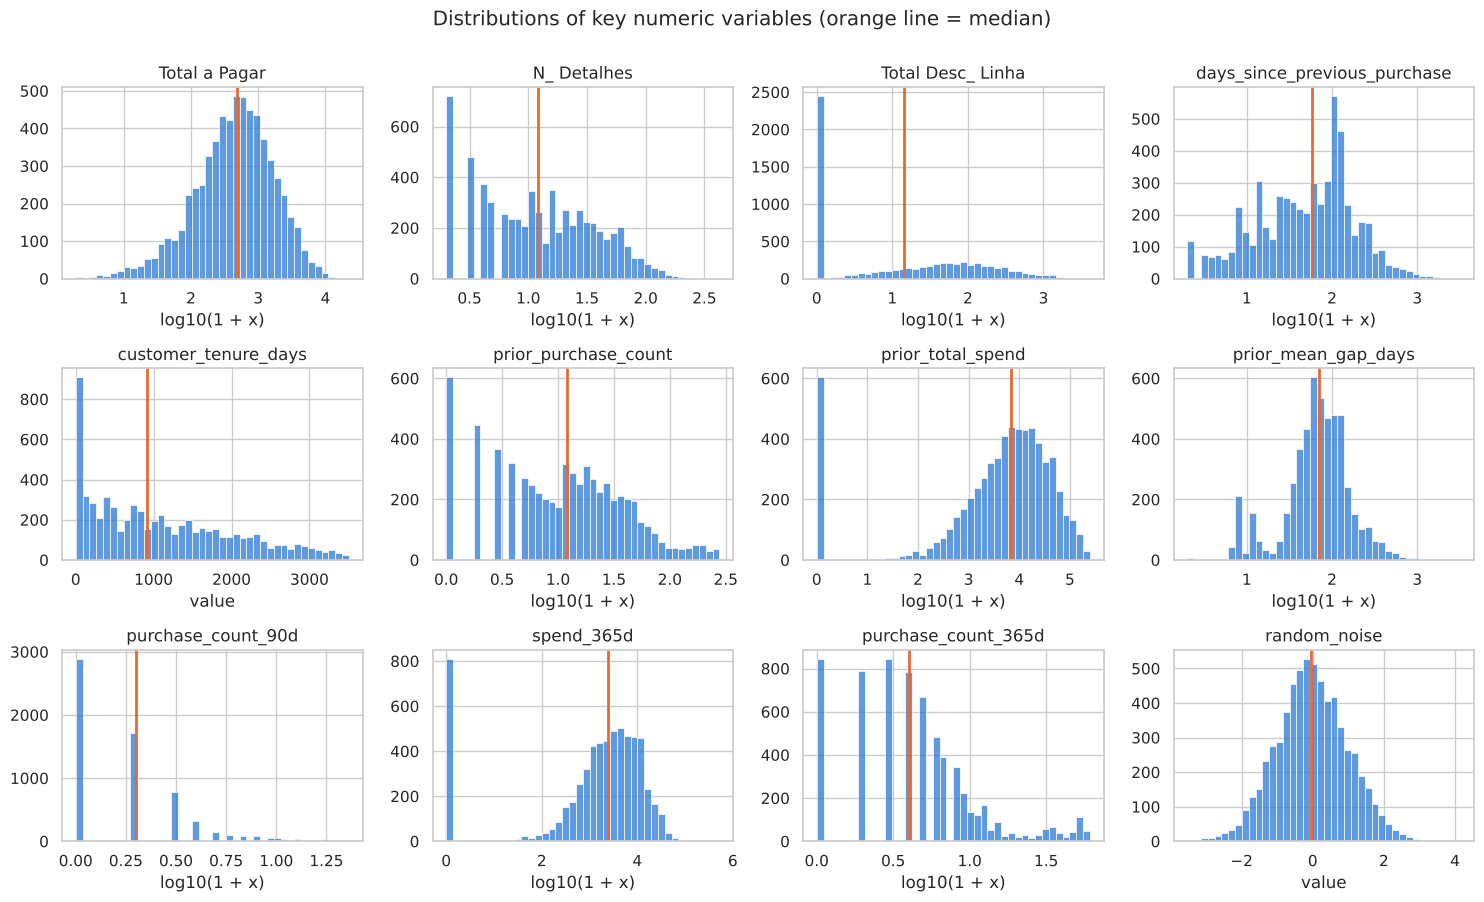

In [23]:
plot_cols = ["Total a Pagar", "N_ Detalhes", "Total Desc_ Linha", "days_since_previous_purchase",
             "customer_tenure_days", "prior_purchase_count", "prior_total_spend",
             "prior_mean_gap_days", "purchase_count_90d", "spend_365d", "purchase_count_365d", "random_noise"]
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.ravel(), plot_cols):
    s = h[col].dropna()
    s = s[s >= 0] if col != "random_noise" else s
    log = col not in ["customer_tenure_days", "random_noise"]
    sns.histplot(np.log10(1 + s) if log else s, bins=40, color=BLUE, ax=ax, edgecolor="white", linewidth=0.5)
    ax.axvline(np.log10(1 + s.median()) if log else s.median(), color=ORANGE, lw=2)
    ax.set(title=col, xlabel="log10(1 + x)" if log else "value", ylabel="")
fig.suptitle("Distributions of key numeric variables (orange line = median)", y=1.0)
plt.tight_layout(); plt.show()

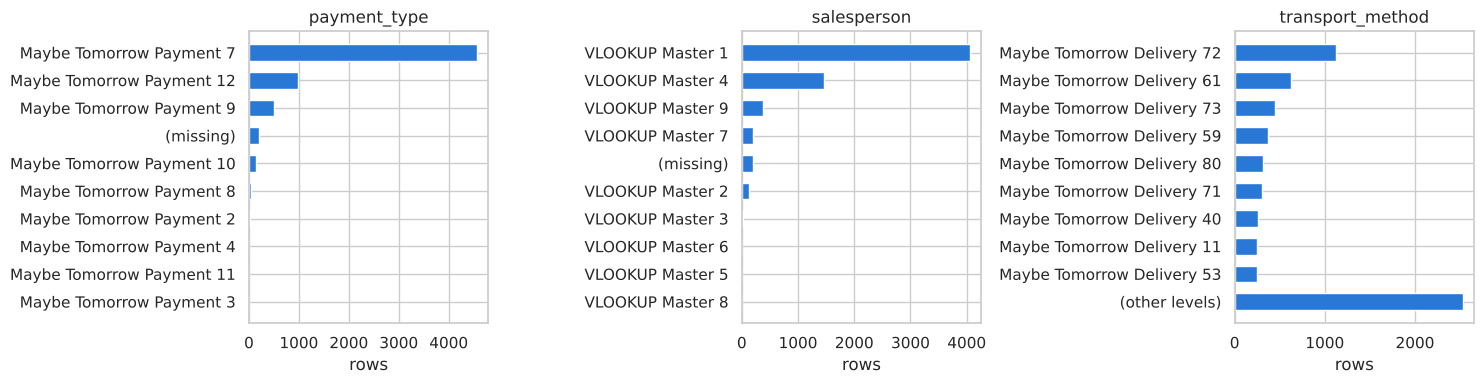

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["payment_type", "salesperson", "transport_method"]):
    vc = tr[col].fillna("(missing)").value_counts()
    vc = pd.concat([vc.head(9), pd.Series({"(other levels)": vc.iloc[9:].sum()})]) if len(vc) > 10 else vc
    vc = vc[vc > 0]
    ax.barh(vc.index[::-1], vc.values[::-1], color=BLUE, height=0.6)
    ax.set(title=col, xlabel="rows")
plt.tight_layout(); plt.show()

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: on a log scale the amounts are close to log-normal, and the history columns have a spike at zero.</b></p>

<ul>
  <li><b>Amounts look log-normal.</b> Total a Pagar, prior_total_spend and spend_365d become roughly bell-shaped after log<sub>10</sub>(1 + x), so a log transform would tame their skew in Task 2.</li>
  <li><b>Zero is a separate group.</b> prior_purchase_count, prior_total_spend and the window counts all have a spike at 0 (first purchases, or no purchase in the window). This is a distinct group, not the low end of a continuum.</li>
  <li><b>Two typical ordering rhythms.</b> days_since_previous_purchase has one peak around two weeks and another around 100 days, which suggests regular ordering cycles.</li>
  <li>customer_tenure_days piles up at 0 (first purchases) and then declines smoothly.</li>
  <li>random_noise is a symmetric bell centred at zero, as expected.</li>
  <li><b>Categoricals are dominated by one level.</b> payment_type and salesperson are each led by one level (Payment 7: 4,565 rows; Master 1: 4,054), and transport_method has a long tail, grouped here as "other levels".</li>
</ul>

</div>

<a id="bi"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>8. Bivariate relationships with the target</h2>

<h3>8.1 Numeric features: one-feature ranking power</h3>

<p>For each numeric feature we compute the ROC AUC of its raw value against the target. An AUC of 0.5 means no signal; values below 0.5 mean that higher values go with fewer repeat purchases. Because AUC only uses the ranking of the values, it is unaffected by skew and scale. Missing rows are left out, and placeholder codes are removed first.</p>

</div>

In [25]:
rows = []
for col in NUMERIC + ["random_noise"]:
    m = h[col].notna()
    auc = roc_auc_score(h.loc[m, TARGET], h.loc[m, col])
    med1 = h.loc[m & (h[TARGET] == 1), col].median()
    med0 = h.loc[m & (h[TARGET] == 0), col].median()
    rows.append({"feature": col, "role": role(col), "AUC": auc, "|AUC - 0.5|": abs(auc - 0.5),
                 "median | repeat": med1, "median | no repeat": med0})
auc_table = pd.DataFrame(rows).set_index("feature").sort_values("|AUC - 0.5|", ascending=False)
auc_table

,role,AUC,|AUC - 0.5|,median | repeat,median | no repeat
feature,,,,,
purchase_count_365d,rolling window,0.753,0.253,5.000,2.000
prior_mean_gap_days,customer history,0.254,0.246,55.500,101.265
purchase_count_180d,rolling window,0.732,0.232,3.000,1.000
spend_365d,rolling window,0.725,0.225,"4,544.380","1,150.160"
purchase_count_90d,rolling window,0.716,0.216,1.000,0.000
spend_180d,rolling window,0.714,0.214,"2,106.220",457.870
prior_purchase_count,customer history,0.701,0.201,17.000,6.000
spend_90d,rolling window,0.699,0.199,746.190,0.000
prior_total_spend,customer history,0.693,0.193,"12,098.990","3,246.525"


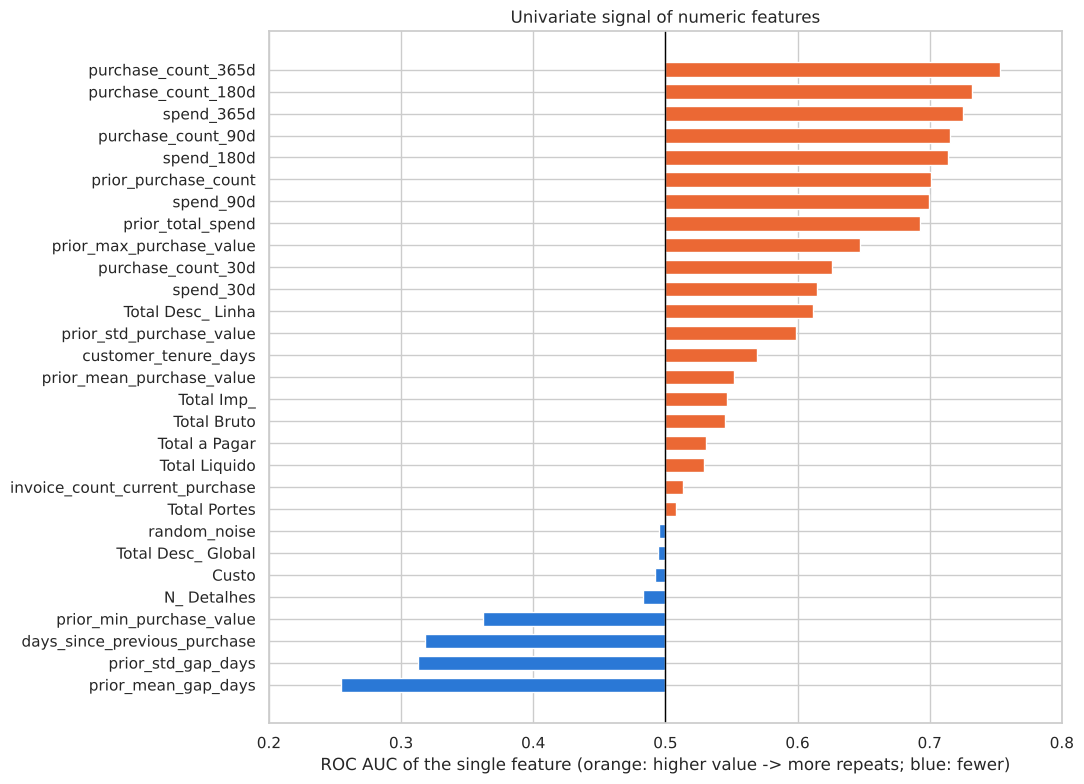

In [26]:
fig, ax = plt.subplots(figsize=(11, 8))
a = auc_table.sort_values("AUC")
colors = [ORANGE if v > 0.5 else BLUE for v in a["AUC"]]
ax.barh(a.index, a["AUC"] - 0.5, left=0.5, color=colors, height=0.65)
ax.axvline(0.5, color="black", lw=1)
ax.set(xlabel="ROC AUC of the single feature (orange: higher value -> more repeats; blue: fewer)",
       title="Univariate signal of numeric features", xlim=(0.2, 0.8))
plt.tight_layout(); plt.show()

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: purchase behaviour predicts the target; the content of the current invoice barely does.</b></p>

<ul>
  <li><b>Frequency is the strongest signal.</b> purchase_count_365d alone reaches <b>AUC 0.753</b>, followed by the 180- and 90-day counts (0.732, 0.716), the 365-day spend (0.725) and the lifetime prior_purchase_count (0.701). Customers who repeat had a median of <b>5 purchases</b> in the past year, those who did not had <b>2</b>.</li>
  <li><b>Regularity and recency are almost as strong, with a negative sign.</b> A short average gap between earlier purchases (prior_mean_gap_days, AUC 0.254, i.e. 0.746 inverted; median 55.5 vs 101.3 days) and a recent previous purchase (days_since_previous_purchase, 0.318; median 37 vs 105 days) both raise the chance of a repeat.</li>
  <li><b>The current invoice contributes little.</b> Its amounts, cost, tax and shipping all lie between AUC 0.48 and 0.55; only line discounts (Total Desc_ Linha, 0.611) stand out a little.</li>
  <li>random_noise (0.495) marks the level of pure chance.</li>
</ul>

<p>This is the classic <b>RFM</b> (recency, frequency, monetary) picture: past purchase frequency and regularity are what separate loyal from occasional customers.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>8.2 The shape of the strongest relationships</h3>

<p>The plots show the repeat rate within bins of the three behavioural dimensions: <b>recency</b>, <b>frequency</b> and <b>customer tenure</b>. The number of rows in each bin is printed along the bottom, so that a high rate in a bin with only a few rows is not over-interpreted. The dashed line marks the overall repeat rate.</p>

</div>

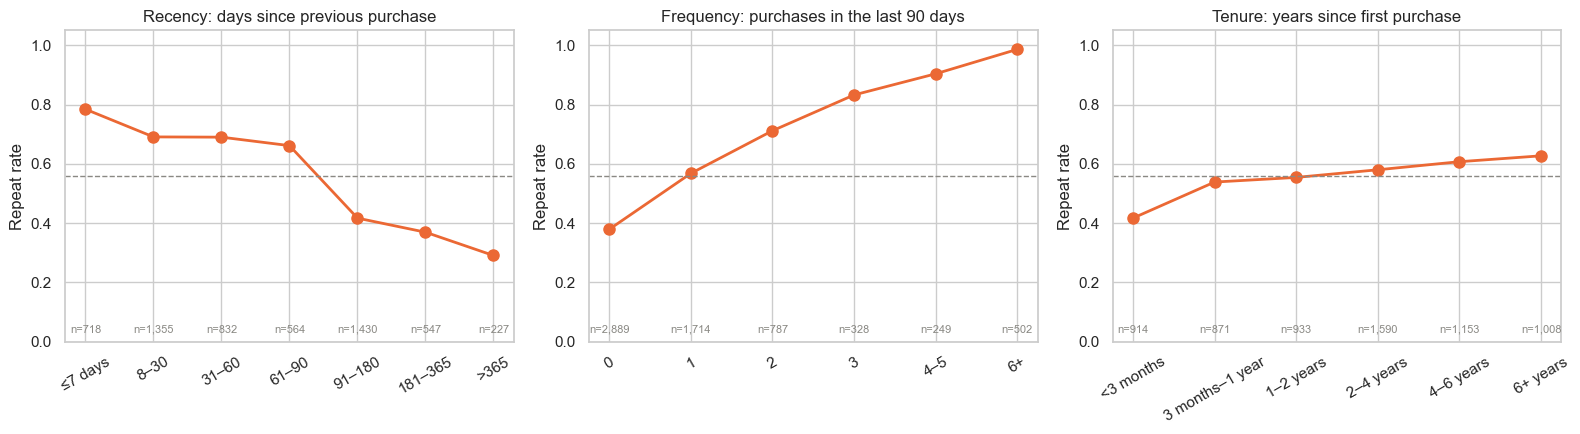

In [39]:
def rate_by_bin(ax, series, bins, labels, title):
    b = pd.cut(series, bins=bins, labels=labels)
    g = h.groupby(b, observed=True)[TARGET].agg(["mean", "size"])
    ax.plot(range(len(g)), g["mean"], marker="o", color=ORANGE, lw=2, ms=8)
    for i, n in enumerate(g["size"]):
        ax.text(i, 0.03, f"n={n:,}", ha="center", fontsize=8, color=GREY)
    ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=30)
    ax.set(ylim=(0, 1.05), ylabel="Repeat rate", title=title)
    ax.axhline(h[TARGET].mean(), color=GREY, ls="--", lw=1)
    return g

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
g_rec = rate_by_bin(axes[0], h["days_since_previous_purchase"], [-10, 7, 30, 60, 90, 180, 365, 5000],
                    ["≤7 days", "8–30", "31–60", "61–90", "91–180", "181–365", ">365"],
                    "Recency: days since previous purchase")
g_frq = rate_by_bin(axes[1], h["purchase_count_90d"], [-1, 0, 1, 2, 3, 5, 100],
                    ["0", "1", "2", "3", "4–5", "6+"], "Frequency: purchases in the last 90 days")
g_ten = rate_by_bin(axes[2], h["customer_tenure_days"] / 365.25, [-0.01, 0.25, 1, 2, 4, 6, 10],
                    ["<3 months", "3 months–1 year", "1–2 years", "2–4 years", "4–6 years", "6+ years"],
                    "Tenure: years since first purchase")
plt.tight_layout(); plt.show()

bins_table = (pd.concat({"Recency": g_rec, "Frequency (90 days)": g_frq, "Tenure": g_ten})
                .rename(columns={"mean": "Repeat rate", "size": "Purchases"})
                .rename_axis(["Dimension", "Group"]))
display(bins_table.style
        .format({"Repeat rate": "{:.1%}", "Purchases": "{:,}"})
        .set_caption("Repeat rate by recency, frequency and tenure")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "", "props": "margin-left:auto; margin-right:auto;"},
                           {"selector": "th", "props": "text-align:center;"}]))

In [28]:
# First-time buyers are a distinct group: no history at all.
first = h["prior_purchase_count"] == 0
print(f"first purchases: {first.sum()} rows, repeat rate {h.loc[first, TARGET].mean():.3f} "
      f"vs {h.loc[~first, TARGET].mean():.3f} for returning customers")

first purchases: 603 rows, repeat rate 0.333 vs 0.583 for returning customers


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: the relationships are monotonic and strong, with a clear threshold near 90 days in recency.</b></p>

<ul>
  <li><b>Recency.</b> The repeat rate is <b>0.78</b> when the previous purchase was at most a week ago, stays at about <b>0.66–0.69 up to 90 days</b>, and then drops sharply to <b>0.42</b> for 91–180 days and <b>0.29</b> beyond a year. The drop exactly at 90 days matches the 90-day definition of the target: a customer whose usual gap is under 90 days is likely to buy again within the window.</li>
  <li><b>Frequency.</b> The rate rises steadily from <b>0.38</b> with no purchase in the last 90 days to <b>0.99</b> with six or more (n = 502). Very active customers are almost certain to repeat.</li>
  <li><b>Tenure.</b> The effect is weaker but monotonic: <b>0.42</b> in the first three months, <b>0.63</b> after six years.</li>
  <li><b>First purchases</b> repeat at only <b>0.333</b>, against <b>0.583</b> for returning customers: a newly acquired customer is the least likely to come back.</li>
</ul>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>8.3 Categorical features</h3>

<p>For each categorical feature we show the repeat rate per level (only levels with at least 30 rows). A chi-square test checks whether the feature and the target are independent, and Cramér's V measures how strong the relationship is (0 = none, 1 = perfect). Missing values are kept as their own level.</p>

</div>

In [29]:
rows = []
for col in CATEGORICAL:
    tab = pd.crosstab(tr[col].fillna("(missing)"), tr[TARGET])
    chi2, p, dof, _ = chi2_contingency(tab)
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    rows.append({"feature": col, "levels": tab.shape[0], "chi2": chi2, "p-value": p, "Cramér's V": v})
pd.DataFrame(rows).set_index("feature").sort_values("Cramér's V", ascending=False)

,levels,chi2,p-value,Cramér's V
feature,,,,
transport_method,81,527.225,0.000,0.285
payment_type,10,354.353,0.000,0.234
salesperson,10,260.760,0.000,0.201
commercial_zone,5,26.295,0.000,0.064
warehouse,3,10.167,0.006,0.040
document_series,3,0.055,0.973,0.003


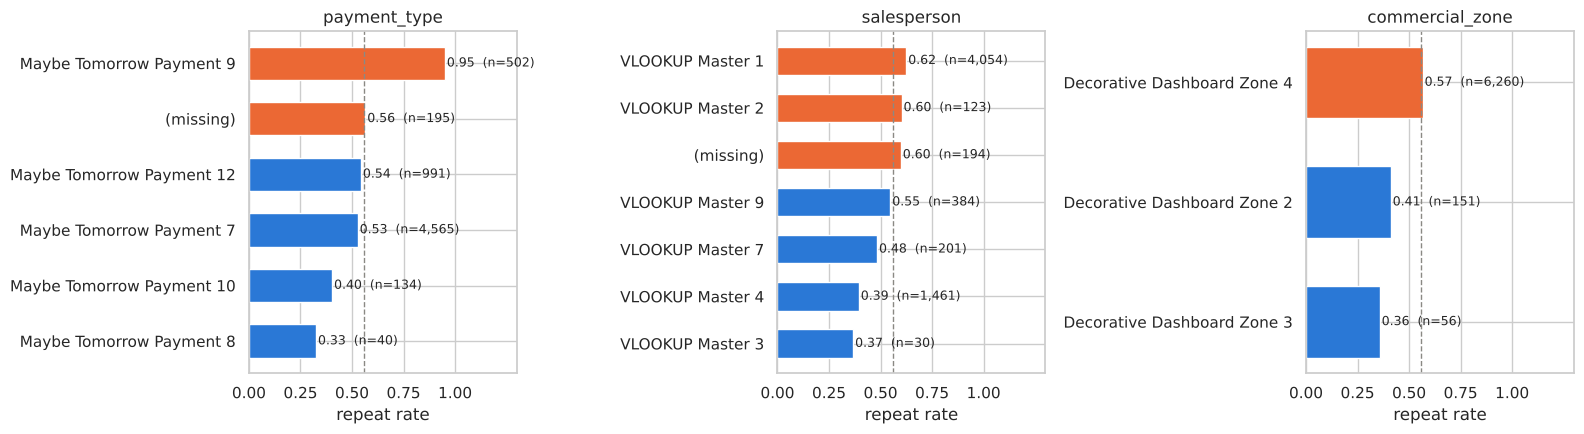

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["payment_type", "salesperson", "commercial_zone"]):
    t = rate_table(tr, col)
    ax.barh(t.index, t["mean"], color=[ORANGE if m > tr[TARGET].mean() else BLUE for m in t["mean"]], height=0.6)
    for i, (m, n) in enumerate(zip(t["mean"], t["size"])):
        ax.text(m + 0.01, i, f"{m:.2f}  (n={n:,})", va="center", fontsize=9)
    ax.axvline(tr[TARGET].mean(), color=GREY, ls="--", lw=1)
    ax.set(xlim=(0, 1.3), xticks=[0, 0.25, 0.5, 0.75, 1], xlabel="repeat rate", title=col)
plt.tight_layout(); plt.show()

In [31]:
# Does the strong payment_type effect survive once frequency is held fixed?
pt = tr["payment_type"].where(tr["payment_type"].isin(["Maybe Tomorrow Payment 7", "Maybe Tomorrow Payment 9",
                                                      "Maybe Tomorrow Payment 12"]), "other / missing")
freq = pd.cut(tr["purchase_count_90d"], [-1, 0, 2, 100], labels=["0", "1-2", "3+"])
pd.crosstab(pt, freq, values=tr[TARGET], aggfunc="mean").round(3).join(
    pd.crosstab(pt, freq).add_prefix("n="))

purchase_count_90d,0,1-2,3+,n=0,n=1-2,n=3+
payment_type,,,,,,
Maybe Tomorrow Payment 12,0.343,0.569,0.931,461,313,217
Maybe Tomorrow Payment 7,0.385,0.619,0.847,2188,1965,412
Maybe Tomorrow Payment 9,0.478,0.852,0.990,23,61,418
other / missing,0.387,0.537,0.875,217,162,32


In [32]:
# Calendar effects
print(rate_table(tr.assign(weekday=tr["purchase_date"].dt.day_name()), "weekday", 1).to_string())

           mean  size
weekday              
Saturday  0.501  3215
Wednesday 0.548    84
Sunday    0.560  1022
Thursday  0.625    24
Tuesday   0.631   683
Friday    0.644   811
Monday    0.671   630


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: payment terms and salesperson are associated with the target, partly through customer behaviour; document_series is not useful.</b></p>

<ul>
  <li><b>payment_type</b> (Cramér's V 0.234): customers on <b>Payment 9 repeat at 0.95</b> (n = 502), against 0.53 for the dominant Payment 7. The cross-tab with 90-day frequency shows why: 418 of the 502 Payment-9 rows belong to customers with 3+ recent purchases, so Payment 9 is largely a marker of very active (probably account) customers. Even at equal frequency it remains higher (e.g. <b>0.852 vs 0.619</b> at 1–2 recent purchases), so it carries some information of its own.</li>
  <li><b>salesperson</b> (V 0.201): Master 1 at <b>0.62</b> vs Master 4 at <b>0.39</b> (n = 1,461), a large difference that likely reflects which customers each one serves.</li>
  <li><b>transport_method</b> has the highest V (0.285), but with 81 levels (including "missing") and many tiny cells the chi-square and V are inflated; this needs rare-level grouping before its value can be judged.</li>
  <li><b>commercial_zone</b> (V 0.064) and <b>warehouse</b> (V 0.040) are weak, as expected from near-constant columns.</li>
  <li><b>document_series</b> (p = 0.97, V 0.003) has <b>no relationship</b> with the target.</li>
  <li><b>Weekdays:</b> Saturday (3,215 rows) has the lowest rate (<b>0.50</b>) and Monday the highest (0.67). The effect is moderate and may reflect customer type (weekend shoppers vs. trade customers) rather than the day itself.</li>
  <li>Missing categorical values have the same repeat rate as the rest (0.55–0.60), so "missing" can be its own level without inventing a signal.</li>
</ul>

</div>

<a id="multi"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>9. Multivariate relationships</h2>

<h3>9.1 Correlation structure</h3>

<p>We use Spearman (rank) correlation instead of Pearson, because nearly every column is skewed and contains outliers. Spearman only compares the ranking of the values, so a few extreme values cannot dominate the result.</p>

</div>

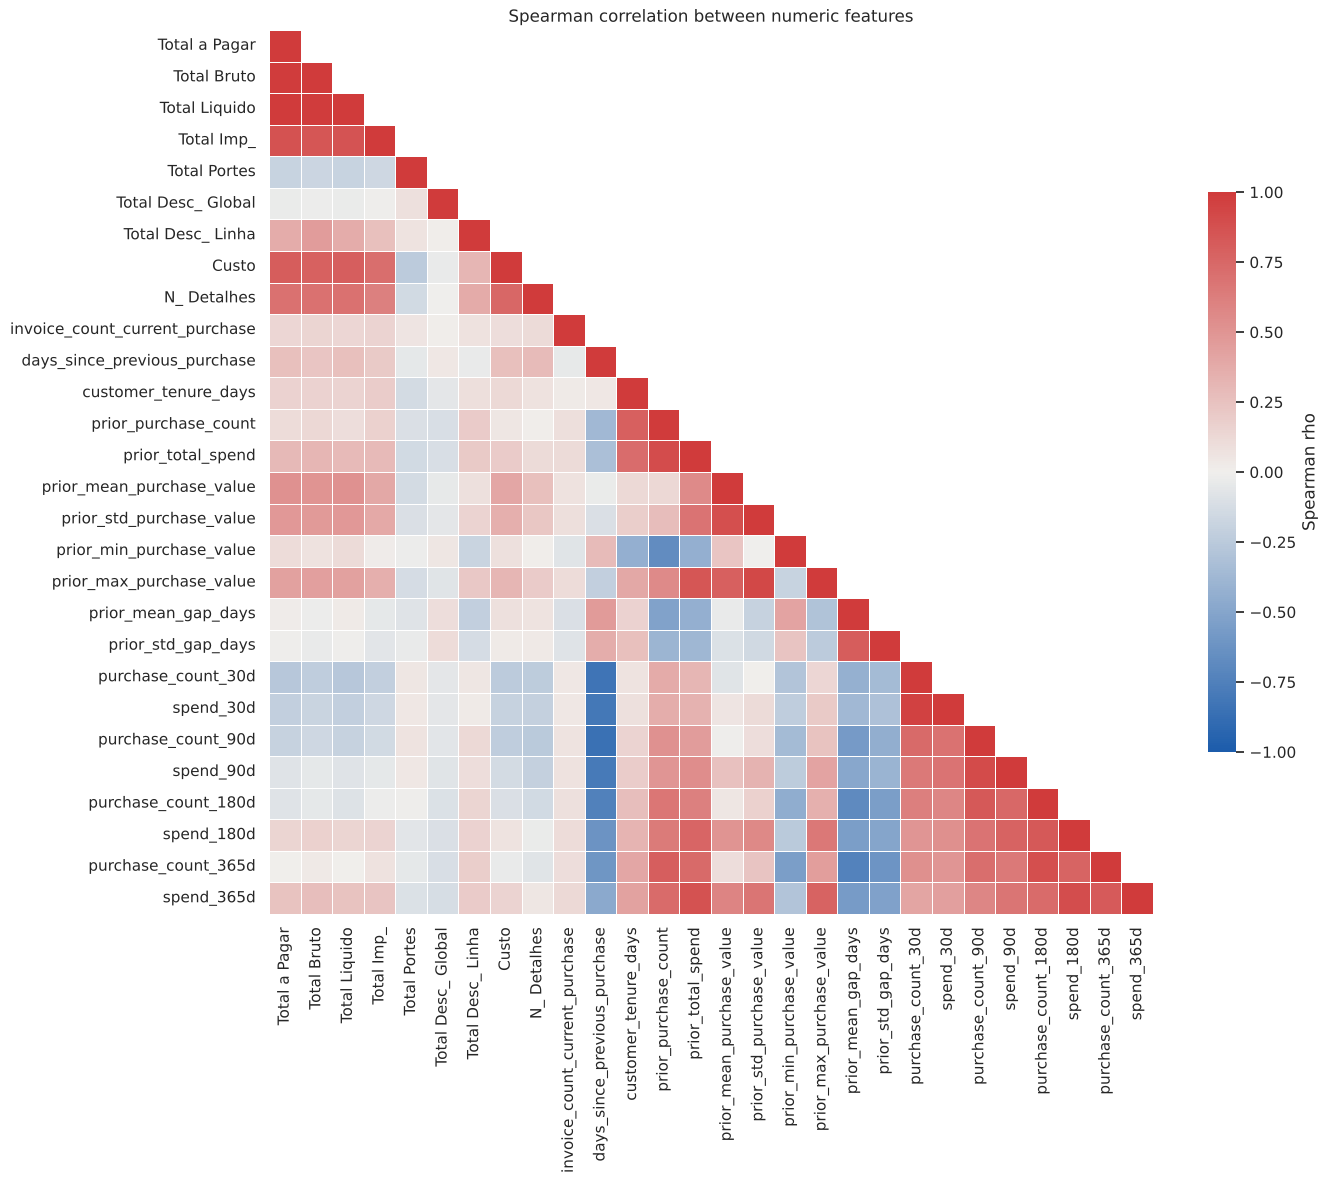

feature pairs with |rho| >= 0.85:
Total a Pagar                 Total Liquido               1.000
Total Bruto                   Total Liquido               0.991
Total a Pagar                 Total Bruto                 0.991
purchase_count_30d            spend_30d                   0.965
prior_std_purchase_value      prior_max_purchase_value    0.923
purchase_count_90d            spend_90d                   0.909
prior_purchase_count          prior_total_spend           0.903
spend_180d                    spend_365d                  0.894
purchase_count_180d           purchase_count_365d         0.888
prior_mean_purchase_value     prior_std_purchase_value    0.883
prior_total_spend             spend_365d                  0.874
Total a Pagar                 Total Imp_                  0.873
Total Liquido                 Total Imp_                  0.862
days_since_previous_purchase  purchase_count_90d         -0.853


In [33]:
corr_cols = INVOICE + HISTORY + WINDOWS
corr = h[corr_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.6, "label": "Spearman rho"}, ax=ax)
ax.set_title("Spearman correlation between numeric features"); ax.grid(False)
plt.tight_layout(); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print("feature pairs with |rho| >= 0.85:")
print(pairs[pairs.abs() >= 0.85].sort_values(ascending=False).round(3).to_string())

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: the numeric features form a few highly redundant clusters.</b></p>

<ul>
  <li><b>Invoice amounts:</b> Total a Pagar, Total Liquido and Total Bruto are virtually the same variable (ρ = 0.99–1.00), with Total Imp_ close behind (0.86–0.87). Together with the exact identities of Section 5.5, one amount column (plus discounts) carries nearly all of this block.</li>
  <li><b>Windows:</b> count and spend in the same window move together (30d: 0.965; 90d: 0.909), as do adjacent windows (180d/365d: 0.89) and lifetime count/spend (0.903).</li>
  <li><b>Recency vs. recent frequency</b> are strongly negative (days_since_previous_purchase vs purchase_count_90d: ρ = −0.853): they measure the same thing from two sides.</li>
  <li><b>The invoice block and the behaviour block are nearly uncorrelated.</b> This matches Section 8: what is bought now says little about whether the customer returns.</li>
</ul>

<p>For Task 3 this means many features can be removed with little loss, and correlation-based filtering or regularisation is needed for linear models.</p>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>9.2 Recency and frequency together</h3>

</div>

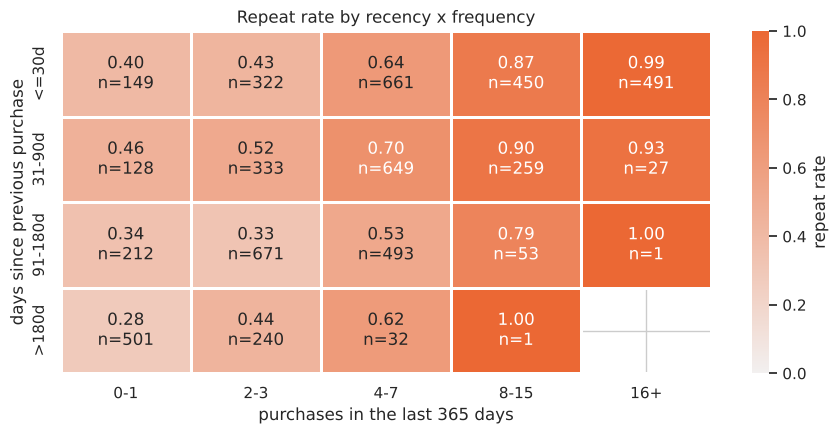

In [34]:
rec = pd.cut(h["days_since_previous_purchase"], [-10, 30, 90, 180, 5000], labels=["<=30d", "31-90d", "91-180d", ">180d"])
frq = pd.cut(h["purchase_count_365d"], [-1, 1, 3, 7, 15, 100], labels=["0-1", "2-3", "4-7", "8-15", "16+"])
grid = h.groupby([rec, frq], observed=False)[TARGET].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(9, 4.5))
annot = grid.apply(lambda r: f"{r['mean']:.2f}\nn={int(r['size'])}" if r["size"] > 0 else "", axis=1).unstack()
sns.heatmap(grid["mean"].unstack(), annot=annot, fmt="", cmap=sns.light_palette(ORANGE, as_cmap=True),
            vmin=0, vmax=1, linewidths=1, linecolor="white", cbar_kws={"label": "repeat rate"}, ax=ax)
ax.set(xlabel="purchases in the last 365 days", ylabel="days since previous purchase",
       title="Repeat rate by recency x frequency")
plt.tight_layout(); plt.show()

In [35]:
# Does the value of the current purchase add anything once frequency is known?
value_q = pd.qcut(h["Total a Pagar"], 4, labels=["Q1 small", "Q2", "Q3", "Q4 large"])
freq3 = pd.cut(h["purchase_count_365d"], [-1, 3, 10, 100], labels=["0-3", "4-10", "11+"])
pd.crosstab(value_q, freq3, values=h[TARGET], aggfunc="mean").round(3)

purchase_count_365d,0-3,4-10,11+
Total a Pagar,,,
Q1 small,0.350,0.618,0.961
Q2,0.320,0.653,0.979
Q3,0.371,0.674,0.969
Q4 large,0.461,0.727,0.950


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: frequency dominates; once it is known, recency adds comparatively little, and the value of the current purchase matters only for infrequent customers.</b></p>

<ul>
  <li><b>Frequency drives the rate.</b> Within each recency band the repeat rate rises strongly with yearly frequency (e.g. for a previous purchase within 30 days: <b>0.40</b> with 0–1 purchases a year to <b>0.99</b> with 16+).</li>
  <li><b>Recency adds little on top.</b> Within a frequency band, recency moves the rate much less and not monotonically (for 2–3 purchases a year: 0.43, 0.52, 0.33, 0.44 across the four recency bands; for 4–7: 0.64, 0.70, 0.53, 0.62). Much of the strong univariate recency effect of Section 8.2 is frequency seen from the other side, which matters for feature selection in Task 3.</li>
  <li><b>Some combinations hardly occur.</b> Some cells are nearly empty (e.g. 16+ purchases a year but last purchase &gt; 90 days ago is almost impossible), which is itself a sign of the strong dependence between the two.</li>
  <li><b>Purchase value matters only for infrequent customers.</b> Among those with 0–3 purchases in the past year, the largest quarter of purchases repeats at <b>0.46</b> vs <b>0.32–0.37</b> for the others. For customers with 4–10 purchases the effect is smaller (0.62 to 0.73), and for those with 11+ it disappears (0.95–0.98). A model with interactions (trees) can use this; a purely additive model will not see it.</li>
</ul>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>9.3 Customers as clusters of rows</h3>

</div>

customers with more than one row: 450; of these, with both outcomes: 77.3%
between-customer share of target variance: 35.0%


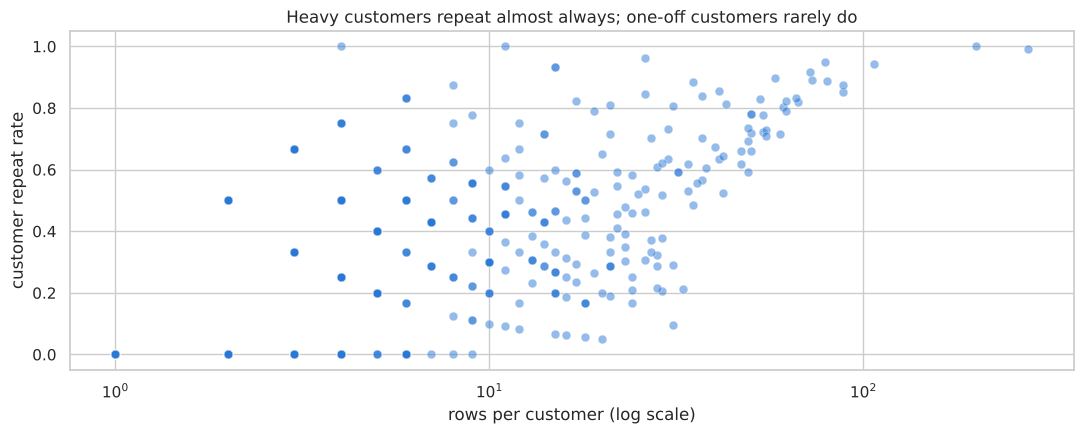

In [36]:
cust = tr.groupby("customer_id")[TARGET].agg(["mean", "size"])
multi = cust[cust["size"] > 1]
print(f"customers with more than one row: {len(multi)}; of these, with both outcomes: "
      f"{((multi['mean'] > 0) & (multi['mean'] < 1)).mean():.1%}")
# Share of target variance explained by the customer alone (between-customer variance)
grand = tr[TARGET].mean()
between = (cust["size"] * (cust["mean"] - grand) ** 2).sum() / len(tr)
print(f"between-customer share of target variance: {between / tr[TARGET].var(ddof=0):.1%}")
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.scatterplot(x=cust["size"], y=cust["mean"], color=BLUE, alpha=0.5, s=40, ax=ax, edgecolor="white")
ax.set(xscale="log", xlabel="rows per customer (log scale)", ylabel="customer repeat rate",
       title="Heavy customers repeat almost always; one-off customers rarely do")
plt.tight_layout(); plt.show()

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: much of the target is a property of the customer.</b></p>

<ul>
  <li><b>450 customers have more than one row</b>; <b>77.3% of them have both outcomes</b>, so the label is not fixed per customer.</li>
  <li>Still, <b>35% of the target variance lies between customers</b>. Customers with many rows repeat almost always, and every customer with a single row has a repeat rate of 0, which is close to tautological: a customer who bought again soon would have produced another row.</li>
  <li><b>Consequence:</b> a random row-level split leaks customer identity into validation and overstates performance. Validation in Task 4 should use <b>GroupKFold by customer_id</b> or a <b>time-based split</b> that mimics the passage of time.</li>
</ul>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>9.4 How the target relates to the customer's next row</h3>

<p>repeat_purchase_90d is defined by <i>future</i> behaviour. Because train holds the customer's consecutive purchases, the next purchase of the same customer is often in the file. The check below compares the target with the gap to the customer's next row in train. This is an <b>exploration of how the label was built</b>, not a feature: a column computed from later rows would not be available at the moment of a real prediction.</p>

</div>

In [37]:
seq = tr.sort_values(["customer_id", "purchase_date"]).copy()
grp = seq.groupby("customer_id")["purchase_date"]
seq["days_to_next_row"] = (grp.shift(-1) - seq["purchase_date"]).dt.days
seq["days_from_prev_row"] = (seq["purchase_date"] - grp.shift(1)).dt.days
seq["next row within 90d"] = np.where(seq["days_to_next_row"].isna(), "no next row",
                                      np.where(seq["days_to_next_row"] <= 90, "yes", "no"))
print(pd.crosstab(seq["next row within 90d"], seq[TARGET], margins=True).to_string())
reconstructed = (seq["days_to_next_row"] <= 90).astype(int)
print(f"\nagreement of 'next row within 90 days' with the target: {(reconstructed == seq[TARGET]).mean():.2%}")
last = seq["days_to_next_row"].isna()
print("repeat rate of each customer's last train row, by year:",
      seq.loc[last].groupby(seq.loc[last, "purchase_date"].dt.year)[TARGET].mean().round(2).to_dict())
print(f"days_since_previous_purchase equals the gap to the previous train row in "
      f"{(seq['days_from_prev_row'] == seq['days_since_previous_purchase']).mean():.1%} of rows")

repeat_purchase_90d     0     1   All
next row within 90d                  
no                   2282    15  2297
no next row           566    41   607
yes                     0  3565  3565
All                  2848  3621  6469

agreement of 'next row within 90 days' with the target: 99.13%
repeat rate of each customer's last train row, by year: {2015: 0.0, 2016: 0.0, 2017: 0.02, 2018: 0.0, 2019: 0.0, 2020: 0.0, 2021: 0.0, 2022: 0.0, 2023: 0.0, 2024: 0.05, 2025: 0.53}
days_since_previous_purchase equals the gap to the previous train row in 86.6% of rows


<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: the target is, almost exactly, "the customer's next purchase in the data comes within 90 days".</b></p>

<ul>
  <li><b>The rule holds on 99.1% of rows.</b> The target equals "the same customer's next row in train is at most 90 days later". Rows with a next row within 90 days are always 1 (3,565 of 3,565); rows with a later next row are 0 in 2,282 of 2,297 cases.</li>
  <li><b>The exceptions have clear causes.</b> Almost all are at the end of train: a customer's last train row is almost always labelled 0 up to 2024 (at most 5% ones per year), but in 2025 more than half (0.53) are labelled 1, because the next purchase falls after the end of this file (February 2025). The other exceptions come from purchases missing from the file: days_since_previous_purchase (computed from the full ledger) equals the gap to the previous train row in only 86.6% of rows.</li>
  <li><b>Implications.</b>
    <ol>
      <li>The target is consistent and well-defined.</li>
      <li>Any feature built from a customer's later rows (e.g. "days to next row") is <b>target leakage</b>: it would score almost perfectly in validation but is not available when a prediction is actually made. Features must be computed only from information up to the purchase date, as the supplied history columns are.</li>
      <li>The look-ahead structure reinforces the need for grouped or time-based validation.</li>
    </ol>
  </li>
</ul>

</div>

<a id="shift"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>10. Stability over time within train</h2>

<p>Train spans almost ten years. If the customer population or the coding of the variables changed over that period, a model fitted on older rows may not hold for later ones. This section compares the periods inside train.</p>

</div>

In [38]:
period = pd.cut(tr["purchase_date"].dt.year, [2014, 2018, 2021, 2025], labels=["2015-2018", "2019-2021", "2022-2025"])
cmp_cols = ["customer_tenure_days", "prior_purchase_count", "prior_total_spend", "days_since_previous_purchase",
            "purchase_count_90d", "purchase_count_365d", "Total a Pagar", "N_ Detalhes"]
medians = h[cmp_cols].groupby(period, observed=True).median().T
medians["repeat rate"] = np.nan
pd.concat([medians.drop(columns="repeat rate"),
           tr.groupby(period, observed=True)[TARGET].mean().to_frame("repeat rate").T,
           period.value_counts().sort_index().to_frame("rows").T])

purchase_date,2015-2018,2019-2021,2022-2025
customer_tenure_days,309.000,"1,119.000","1,918.000"
prior_purchase_count,4.000,14.000,20.000
prior_total_spend,"2,275.790","8,205.470","14,094.630"
days_since_previous_purchase,49.000,57.000,64.000
purchase_count_90d,1.000,1.000,1.000
purchase_count_365d,3.000,4.000,4.000
Total a Pagar,382.060,450.070,620.285
N_ Detalhes,9.000,10.000,15.000
repeat rate,0.562,0.555,0.562
rows,"2,141.000","2,098.000","2,230.000"


In [39]:
print("document_series by year:")
print(pd.crosstab(tr["purchase_date"].dt.year, tr["document_series"]).to_string())
for col in ["salesperson", "payment_type", "commercial_zone"]:
    print(f"\n{col}: share by period (levels with >= 1% of rows)")
    t = pd.crosstab(tr[col], period, normalize="columns").round(3)
    print(t[t.max(axis=1) >= 0.01].to_string())

document_series by year:
document_series  Ctrl Z Series 1  Ctrl Z Series 2  Ctrl Z Series 3
purchase_date                                                     
2015                           0                0              335
2016                           0                0              420
2017                         281                0              389
2018                         387                0              329
2019                         397                0              249
2020                         532                0              138
2021                         231              508               43
2022                           0              628                0
2023                           0              767                0
2024                           0              757                0
2025                           0               78                0

salesperson: share by period (levels with >= 1% of rows)
purchase_date     2015-2018  2019-2021  2022-2

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<p><b>Insight: the repeat rate is stable over time, but the customer base matures and some codes are tied to time.</b></p>

<ul>
  <li><b>The target is stable:</b> 0.562, 0.555 and 0.562 in the three periods, each with about 2,100–2,200 rows.</li>
  <li><b>Lifetime features drift upwards by construction.</b> Median tenure grows from <b>309 days (2015–2018) to 1,918 (2022–2025)</b>, lifetime purchases from <b>4 to 20</b>, lifetime spend from <b>2,276 to 14,095</b>. This is not a change in behaviour: the data begins in 2015, so early rows cannot have a long history. A model that leans on lifetime totals learns partly <i>when</i> a row was recorded. Recent-behaviour features are far more stable (median purchases in the last 90 days 1 / 1 / 1, last 365 days 3 / 4 / 4; recency 49 / 57 / 64 days), so they should generalise better to later data.</li>
  <li><b>document_series is a clock, not a property of the customer.</b> Series 3 runs 2015–2021, Series 1 2017–2021, and Series 2 only from 2021 onwards. Combined with its zero association with the target (Section 8.3), it should be dropped.</li>
  <li><b>Category levels appear and disappear.</b> Salesperson Master 9 exists only from 2022 (17.7% of recent rows), while Masters 2, 3 and 7 occur only before 2019; commercial_zone Zone 2 grows from 0% to 5.2%. Encoders in Task 2 must therefore handle levels not seen during fitting (e.g. handle_unknown="ignore" or an "other" level), and rare or retired levels should be grouped.</li>
  <li><b>Purchases become larger over time</b> (median Total a Pagar <b>382 → 620</b>), partly due to price development, which is one more reason to rely on behaviour rather than amounts.</li>
</ul>

</div>

<a id="summary"></a>
<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h2>11. Summary of insights and implications for Task 2</h2>

</div>

<div style="background-color:#e6f2fb; padding:20px 24px; border-radius:0;">

<h3>What the data is</h3>
<ul>
  <li><b>6,534 purchases from 610 customers</b> (2015-07 to 2025-02) in train.csv; test.csv is held back for the final evaluation of the model and was not used.</li>
  <li><b>Target</b> repeat_purchase_90d: 55.9% positive; majority baseline accuracy 0.559; stable over time.</li>
  <li><b>Five blocks of features:</b> current invoice, customer history, rolling windows, categorical codes, and identifiers/noise. clientes.csv adds static customer attributes, mostly sparse or identifier-like.</li>
</ul>

<h3>Key insights</h3>
<ul>
  <li><b>Behaviour drives repeat purchases.</b> Frequency (purchase_count_365d, AUC 0.75), regularity (prior_mean_gap_days) and recency (days_since_previous_purchase) dominate; the repeat rate falls sharply once the previous purchase is more than 90 days ago, and rises to 0.99 for customers with 6+ purchases in 90 days. The current invoice's amounts carry almost no signal.</li>
  <li><b>First purchases are a distinct group</b> (603 rows, repeat rate 0.33).</li>
  <li><b>payment_type</b> (Payment 9: 0.95) and <b>salesperson</b> matter, partly as markers of very active customers.</li>
  <li><b>Strong redundancy:</b> two invoice columns are exact linear combinations of others; amount, count/spend and window features form highly correlated clusters.</li>
  <li><b>The label is "next purchase within 90 days"</b>, confirmed on 99.1% of rows. Features derived from later rows would leak the target.</li>
  <li><b>Rows are clustered by customer</b> (35% of target variance between customers), and lifetime features and category levels drift over time, while recent-behaviour features stay stable.</li>
</ul>

<h3>Data quality issues and decisions for Task 2</h3>
<table>
  <tr><th>#</th><th>Issue</th><th>Extent</th><th>Proposed handling (to be justified in Task 2)</th></tr>
  <tr><td>1</td><td>Completely empty rows</td><td>65 rows</td><td>Drop</td></tr>
  <tr><td>2</td><td>Structural missing history (first / second purchase)</td><td>603 / 445 / 365 rows</td><td>Indicator + neutral fill, not median imputation</td></tr>
  <tr><td>3</td><td>Missing at random in history and 4 categoricals</td><td>≈3% per column</td><td>Impute (median / mode or "missing" level), fitted on train only</td></tr>
  <tr><td>4</td><td>Placeholder 1e9, negative amounts, −4 days</td><td>94 rows</td><td>Set to missing, then recompute from consistent columns or impute</td></tr>
  <tr><td>5</td><td>Remaining inconsistent history values</td><td>39–46 rows per rule</td><td>Recompute the mean (total / count); set inflated max and spend_365d to missing and impute</td></tr>
  <tr><td>6</td><td>Exact identities in invoice amounts</td><td>2 redundant columns</td><td>Keep one representation</td></tr>
  <tr><td>7</td><td>Heavy right skew, many zeros</td><td>Most amount columns</td><td>Log transform; zero indicators where useful</td></tr>
  <tr><td>8</td><td>Rare, retired and new category levels</td><td>transport_method 80 levels; salesperson levels change over time</td><td>Group rare levels; encoder that ignores unknown levels</td></tr>
  <tr><td>9</td><td>Identifier-like / noise columns</td><td>ID, customer_id, random_noise, document_series</td><td>Exclude from features (ID kept as row key, customer_id for joins and grouping)</td></tr>
  <tr><td>10</td><td>clientes.csv</td><td>Complete coverage, mostly sparse</td><td>Join; try country_or_region and an island-known flag; drop identifiers and customer_type</td></tr>
</table>

<h3>Implications for modelling</h3>
<ul>
  <li>Use <b>grouped (by customer_id) or time-based validation</b> within train, never a plain random split.</li>
  <li>Report a metric that is robust to the 56/44 imbalance (<b>ROC AUC</b>, with F1 or balanced accuracy) and always compare with the <b>0.559 majority baseline</b>.</li>
</ul>

</div>